In [1]:
import os.path
import matplotlib.cm as cm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import csv
from collections import defaultdict
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D


In [9]:
files = [
    "2026-02-10_finbench_0.1_latency.csv",
    "2026-02-10_finbench_0.3_latency.csv",
    "2026-02-09_finbench_1_latency.csv",
    "2026-02-09_finbench_3_latency.csv",
    "2026-02-09_snb_1_latency.csv",
    "2026-02-10_snb_3_latency.csv"
]

finbench_query_name = {
    1 : 'RJ-1',
    2: 'RJ-2',
    3: 'J-1',
    4: 'RJ-3',
    5: 'S-1',
    6: 'S-2',
    7: 'RJ-4',
    8: 'J-2',
    9: 'R-1',
    10: 'MM-1',
    11: 'S-3',
    12: 'S-4',
    13: 'MM-2',
    14: 'MM-3',
    15: 'S-5',
    16: 'S-6',
    17: 'S-7',
    18: 'F-1*',
    19: 'SQ-1*',
    20:'SQU-1*'
}

snb_query_name = {
    1 : 'MM-1',
    2: 'MM-2',
    3: 'R-1',
    4: 'SQU-1',
    5: 'MM-3',
    6: 'MM-4',
    7: 'J-1',
    8: 'MM-5',
    9: 'R-2',
    10: 'MMJ-1',
    11: 'MMJ-2',
    12: 'R-3',
    13: 'MM-6',
    14: 'MMJ-3',
    15: 'SQU-2',
    16: 'MMJ-4',
    17: 'S-1',
    18: 'J-2',
    19: 'J-3',
    20: 'F-1*'
}

snb_custom_order = ['S-1','F-1*','J-1','J-2','J-3','MM-1','MM-2','MM-3',
                    'MM-4','MM-5','MM-6','MMJ-1','MMJ-2','MMJ-3','MMJ-4','R-1','R-2','R-3','SQU-1','SQU-2']
finbench_custom_order = ['S-1','S-2','S-3','S-4','S-5','S-6','S-7', 'F-1*',
                         'MM-1','MM-2','MM-3','J-1','J-2','R-1','RJ-1','RJ-2','RJ-3','RJ-4','SQ-1*','SQU-1*']

custom_orders = {
    "Finbench": finbench_custom_order,
    "SNB-BI": snb_custom_order,
}

dataset_mapping = {
    "finbench": "Finbench",
    "snb": "SNB-BI"
}

ORIG_COLOR = "#1f77b4"
PROV_COLOR = "#ff7f0e"
DIFF_COLOR = "#d62728"  # Color for the difference

prov_order = ["Why", "Where"]
legend = {
    "Why": True,
    "Where": False
}

df = pd.concat([pd.read_csv(os.path.join("result/metrics/run_1", f)) for f in files], ignore_index=True)


Saved plot to ./result/new_plots/Finbench_execution_time_Why-log.png


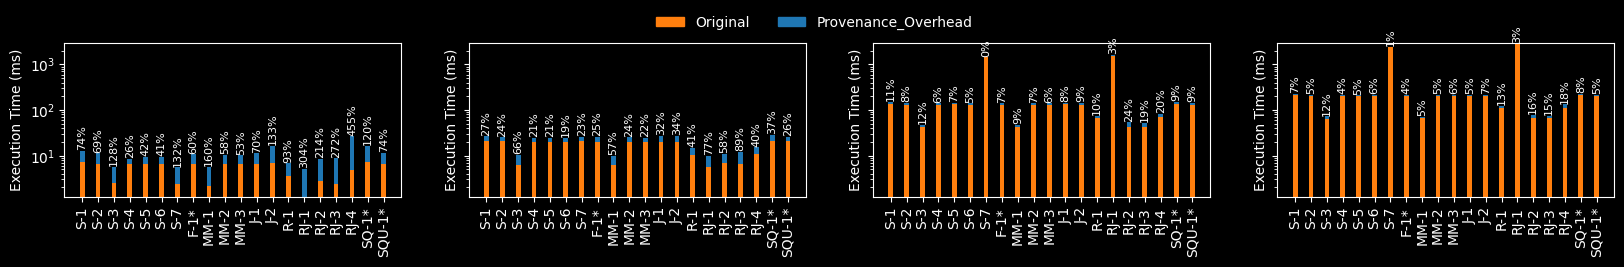

Saved plot to ./result/new_plots/Finbench_execution_time_Where-log.png


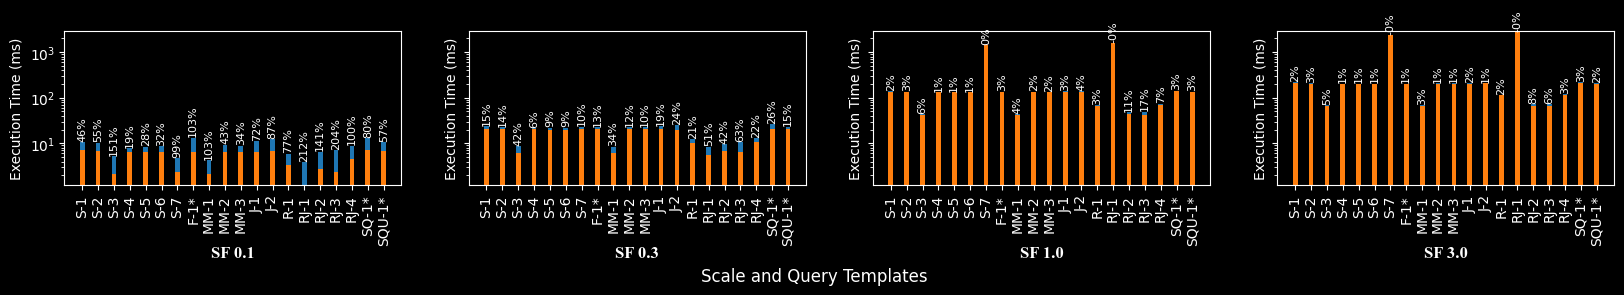

Saved plot to ./result/new_plots/SNB-BI_execution_time_Why-log.png


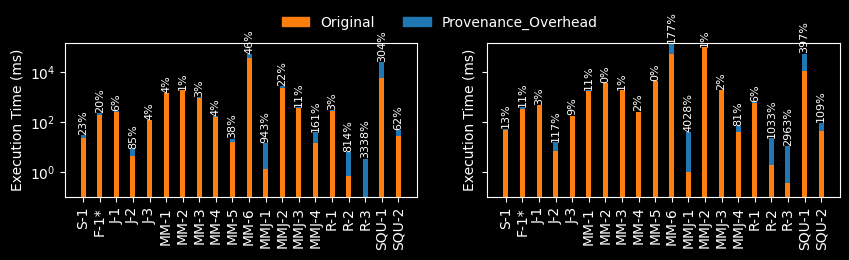

Saved plot to ./result/new_plots/SNB-BI_execution_time_Where-log.png


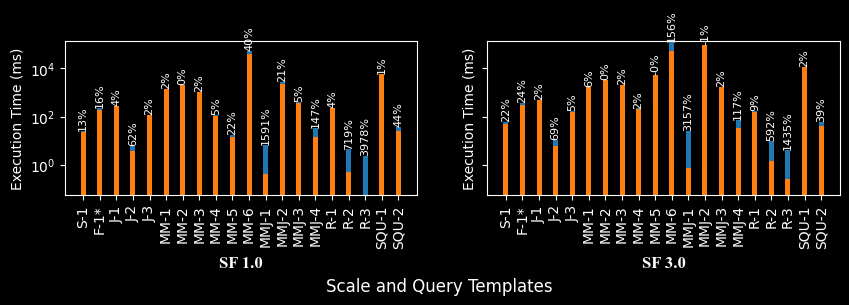

In [10]:
df["query_type"] = df["query"].str.extract(r'^(prov|orig)')
df["query_id"] = df["query"].str.extract(r'^(?:prov|orig)_(?:finbench|snb)-([\d.]+)_')

# Keep only integers or decimals ending in .3
df = df[df["query_id"].str.match(r"^\d+$|^\d+\.3$")]

# Rename .3 queries to integer part
df["query_id"] = df["query_id"].str.replace(r"\.3$", "", regex=True)
df["query_id"] = df["query_id"].astype(int)

df["query_name"] = None

df.loc[df["dataset"] == "finbench", "query_name"] = (
    df.loc[df["dataset"] == "finbench", "query_id"].map(finbench_query_name)
)

df.loc[df["dataset"] == "snb", "query_name"] = (
    df.loc[df["dataset"] == "snb", "query_id"].map(snb_query_name)
)

df["dataset"] = df["dataset"].map(dataset_mapping).fillna(df["dataset"])

agg2 = (
    df.groupby(["provModel", "dataset","scaleFactor", "query_name", "query_type", "parameter"], as_index=False)
    .agg(mean_exec_time=("mean", "mean"))
)

agg = (
    agg2.groupby(
        ["provModel", "dataset", "scaleFactor", "query_name", "query_type"],
        as_index=False
    )
    .agg(mean_exec_time=("mean_exec_time", "mean"))
)

def per_dataset_overhead_log(dataset_name):
    for prov_model in prov_order:
        if prov_model not in agg["provModel"].values:
            continue  # skip if this provenance model is not in the data

        # Filter by provenance model and dataset
        sub_model = agg[(agg["provModel"] == prov_model) & (agg["dataset"] == dataset_name)].copy()

        # Determine common y-axis limits across all scaleFactors
        all_vals = pd.concat([
            sub_model[sub_model["query_type"]=="orig"]["mean_exec_time"],
            sub_model[sub_model["query_type"]=="prov"]["mean_exec_time"]
        ])
        Y_MIN = all_vals[all_vals > 0].min()  # log scale cannot include 0
        Y_MAX = all_vals.max() * 1.05  # small margin

        # Unique scale factors
        dataset_scale_order = sub_model[["scaleFactor"]].drop_duplicates().sort_values("scaleFactor")["scaleFactor"].values
        n_scales = len(dataset_scale_order)

        # Create subplots with shared y-axis
        fig, axes = plt.subplots(1, n_scales, figsize=(5*n_scales, 2), sharey=True)
        if n_scales == 1:
            axes = [axes]  # make it iterable

        for i, scale in enumerate(dataset_scale_order):
            ax = axes[i]
            sub = sub_model[sub_model["scaleFactor"] == scale].copy()

            # Order queries if custom order exists
            order_list = custom_orders.get(dataset_name, [])
            sub["order"] = sub["query_name"].apply(lambda q: order_list.index(q) if q in order_list else np.inf)
            sub = sub.sort_values("order")
            queries = sub["query_name"].unique()
            x = np.arange(len(queries))
            bar_width = 0.3

            # Extract execution times
            orig = sub[sub["query_type"]=="orig"].set_index("query_name").reindex(queries)["mean_exec_time"]
            prov = sub[sub["query_type"]=="prov"].set_index("query_name").reindex(queries)["mean_exec_time"]

            # Plot bars
            ax.bar(x, orig, bar_width, color=PROV_COLOR)
            # ax.bar(x + bar_width/2, prov, bar_width, color=PROV_COLOR)


            # Log scale
            ax.set_yscale("log")
            ax.set_ylim(Y_MIN, Y_MAX)

            # X-axis labels
            ax.set_xticks(x)
            ax.set_xticklabels(queries, rotation=90)
            ax.set_ylabel("Execution Time (ms)")

            # Annotate difference percentages
            for xi, o, p in zip(x, orig, prov):
                diff_pct = ((p - o) / o * 100)
                ypos = max(o, p) * 1.05
                if diff_pct != 0:
                    ax.text(xi, ypos, f"{diff_pct:.0f}%", ha='center', va='bottom', fontsize=8, rotation=90)

                # diff overlay
                if p > o:
                    ax.bar(xi, p - o, bar_width, bottom=o, color=ORIG_COLOR)
                else:
                    ax.bar(xi, o - p, bar_width, bottom=p, color=ORIG_COLOR)

            if not (legend[prov_model]):
                ax.text(
                    0.5,              # horizontal center
                    -0.4,             # y position below the axes (negative)
                    f"SF {scale}",    # text
                    fontsize=12,
                    ha='center',      # horizontal alignment
                    va='top',         # vertical alignment relative to the y position
                    transform=ax.transAxes ,
                    fontweight='bold',       # make text bold
                    fontname='Times New Roman' # set font
                )
        if not (legend[prov_model]):
            fig.text(
                0.5,              # horizontal center
                -0.3,             # y position below the axes (negative)
                f"Scale and Query Templates",    # text
                fontsize=12,
                ha='center',      # horizontal alignment
                va='top'        # vertical alignment relative to the y position
            )

        # Add overall figure title and legend
        orig_patch = mpatches.Patch(color=PROV_COLOR, label="Original")
        prov_patch = mpatches.Patch(color=ORIG_COLOR, label="Provenance_Overhead")
        if legend[prov_model]:
            fig.legend(handles=[orig_patch, prov_patch], loc="upper center",
                   bbox_to_anchor=(0.5, 1.08), ncol=2, frameon=False)
        # fig.suptitle(f"Execution Time Comparison – {prov_model} – {dataset_name}", fontsize=14, y=1.05)

        os.makedirs("./result/new_plots", exist_ok=True)
        filename = f"./result/new_plots/{dataset_name}_execution_time_{prov_model}-log.png"
        fig.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Saved plot to {filename}")
        plt.show()


per_dataset_overhead_log("Finbench")
per_dataset_overhead_log("SNB-BI")


Saved plot to ./result/new_plots/Finbench_execution_time_Why-dot.png


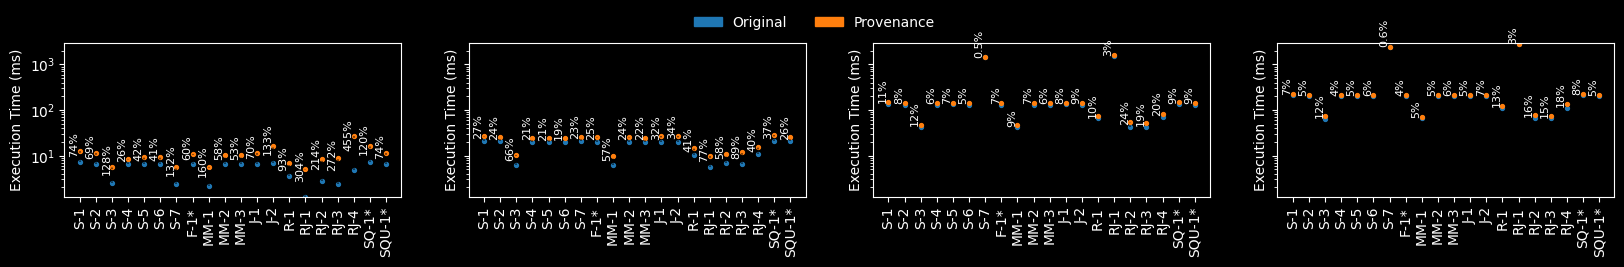

Saved plot to ./result/new_plots/Finbench_execution_time_Where-dot.png


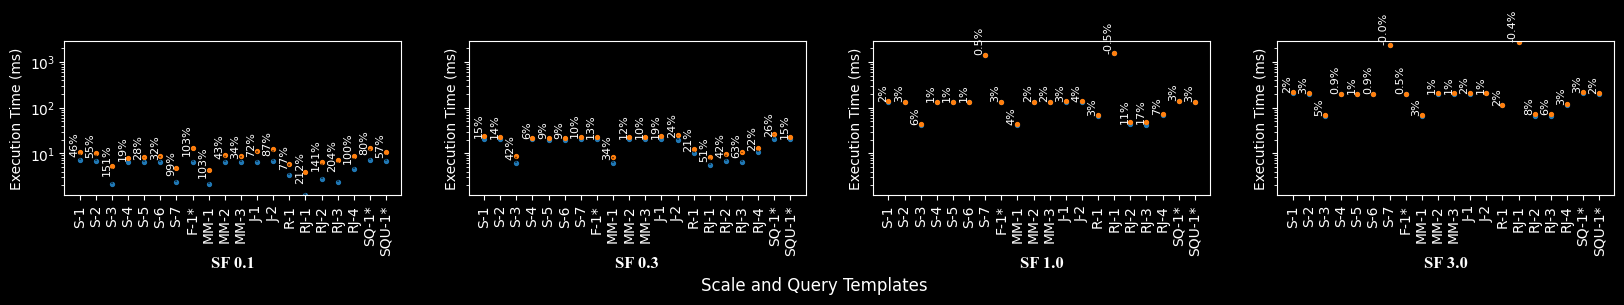

Saved plot to ./result/new_plots/SNB-BI_execution_time_Why-dot.png


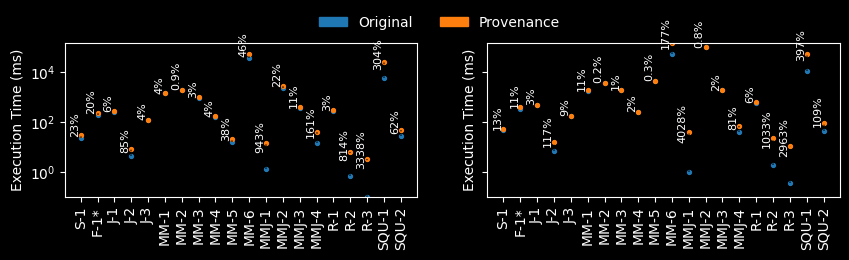

Saved plot to ./result/new_plots/SNB-BI_execution_time_Where-dot.png


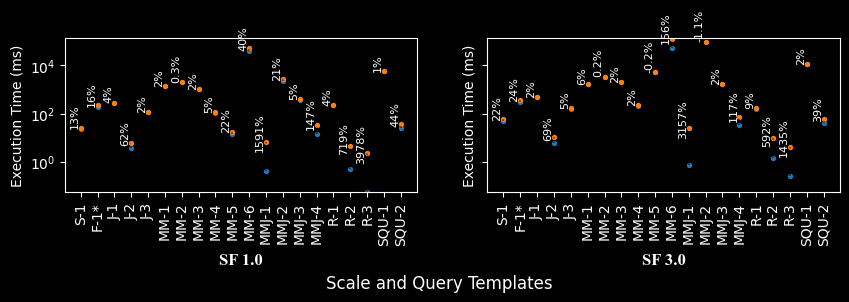

In [12]:
files = [
    "2026-02-10_finbench_0.1_latency.csv",
    "2026-02-10_finbench_0.3_latency.csv",
    "2026-02-09_finbench_1_latency.csv",
    "2026-02-09_finbench_3_latency.csv",
    "2026-02-09_snb_1_latency.csv",
    "2026-02-10_snb_3_latency.csv"
]

finbench_query_name = {
    1 : 'RJ-1',
    2: 'RJ-2',
    3: 'J-1',
    4: 'RJ-3',
    5: 'S-1',
    6: 'S-2',
    7: 'RJ-4',
    8: 'J-2',
    9: 'R-1',
    10: 'MM-1',
    11: 'S-3',
    12: 'S-4',
    13: 'MM-2',
    14: 'MM-3',
    15: 'S-5',
    16: 'S-6',
    17: 'S-7',
    18: 'F-1*',
    19: 'SQ-1*',
    20:'SQU-1*'
}

snb_query_name = {
    1 : 'MM-1',
    2: 'MM-2',
    3: 'R-1',
    4: 'SQU-1',
    5: 'MM-3',
    6: 'MM-4',
    7: 'J-1',
    8: 'MM-5',
    9: 'R-2',
    10: 'MMJ-1',
    11: 'MMJ-2',
    12: 'R-3',
    13: 'MM-6',
    14: 'MMJ-3',
    15: 'SQU-2',
    16: 'MMJ-4',
    17: 'S-1',
    18: 'J-2',
    19: 'J-3',
    20: 'F-1*'
}

snb_custom_order = ['S-1','F-1*','J-1','J-2','J-3','MM-1','MM-2','MM-3',
                    'MM-4','MM-5','MM-6','MMJ-1','MMJ-2','MMJ-3','MMJ-4','R-1','R-2','R-3','SQU-1','SQU-2']
finbench_custom_order = ['S-1','S-2','S-3','S-4','S-5','S-6','S-7', 'F-1*',
                         'MM-1','MM-2','MM-3','J-1','J-2','R-1','RJ-1','RJ-2','RJ-3','RJ-4','SQ-1*','SQU-1*']

custom_orders = {
    "Finbench": finbench_custom_order,
    "SNB-BI": snb_custom_order,
}

dataset_mapping = {
    "finbench": "Finbench",
    "snb": "SNB-BI"
}

ORIG_COLOR = "#1f77b4"
PROV_COLOR = "#ff7f0e"
DIFF_COLOR = "#d62728"  # Color for the difference

prov_order = ["Why", "Where"]
legend = {
    "Why": True,
    "Where": False
}

df = pd.concat([pd.read_csv(os.path.join("result/metrics/run_1", f)) for f in files], ignore_index=True)


df["query_type"] = df["query"].str.extract(r'^(prov|orig)')
df["query_id"] = df["query"].str.extract(r'^(?:prov|orig)_(?:finbench|snb)-([\d.]+)_')

# Keep only integers or decimals ending in .3
df = df[df["query_id"].str.match(r"^\d+$|^\d+\.3$")]

# Rename .3 queries to integer part
df["query_id"] = df["query_id"].str.replace(r"\.3$", "", regex=True)
df["query_id"] = df["query_id"].astype(int)

df["query_name"] = None

df.loc[df["dataset"] == "finbench", "query_name"] = (
    df.loc[df["dataset"] == "finbench", "query_id"].map(finbench_query_name)
)

df.loc[df["dataset"] == "snb", "query_name"] = (
    df.loc[df["dataset"] == "snb", "query_id"].map(snb_query_name)
)

df["dataset"] = df["dataset"].map(dataset_mapping).fillna(df["dataset"])

agg2 = (
    df.groupby(["provModel", "dataset","scaleFactor", "query_name", "query_type", "parameter"], as_index=False)
    .agg(mean_exec_time=("mean", "mean"))
)

agg = (
    agg2.groupby(
        ["provModel", "dataset", "scaleFactor", "query_name", "query_type"],
        as_index=False
    )
    .agg(mean_exec_time=("mean_exec_time", "mean"))
)

def per_dataset_overhead_log(dataset_name):
    for prov_model in prov_order:
        if prov_model not in agg["provModel"].values:
            continue  # skip if this provenance model is not in the data

        # Filter by provenance model and dataset
        sub_model = agg[(agg["provModel"] == prov_model) & (agg["dataset"] == dataset_name)].copy()

        # Determine common y-axis limits across all scaleFactors
        all_vals = pd.concat([
            sub_model[sub_model["query_type"]=="orig"]["mean_exec_time"],
            sub_model[sub_model["query_type"]=="prov"]["mean_exec_time"]
        ])
        Y_MIN = all_vals[all_vals > 0].min()  # log scale cannot include 0
        Y_MAX = all_vals.max() * 1.05  # small margin

        # Unique scale factors
        dataset_scale_order = sub_model[["scaleFactor"]].drop_duplicates().sort_values("scaleFactor")["scaleFactor"].values
        n_scales = len(dataset_scale_order)

        # Create subplots with shared y-axis
        fig, axes = plt.subplots(1, n_scales, figsize=(5*n_scales, 2), sharey=True)
        if n_scales == 1:
            axes = [axes]  # make it iterable

        for i, scale in enumerate(dataset_scale_order):
            ax = axes[i]
            sub = sub_model[sub_model["scaleFactor"] == scale].copy()

            # Order queries if custom order exists
            order_list = custom_orders.get(dataset_name, [])
            sub["order"] = sub["query_name"].apply(lambda q: order_list.index(q) if q in order_list else np.inf)
            sub = sub.sort_values("order")
            queries = sub["query_name"].unique()
            x = np.arange(len(queries))
            bar_width = 0.35

            # Extract execution times
            orig = sub[sub["query_type"]=="orig"].set_index("query_name").reindex(queries)["mean_exec_time"]
            prov = sub[sub["query_type"]=="prov"].set_index("query_name").reindex(queries)["mean_exec_time"]

            # Plot bars
            ax.plot(x, orig, marker='o', linestyle='', color=ORIG_COLOR,    markersize=3,      # ↓ smaller markers
            markeredgewidth=0.8)
            ax.plot(x, prov, marker='o', linestyle='', color=PROV_COLOR,     markersize=3,      # ↓ smaller markers
                    markeredgewidth=0.8)


    # Log scale
            ax.set_yscale("log")
            ax.set_ylim(Y_MIN, Y_MAX)

            # X-axis labels
            ax.set_xticks(x)
            ax.set_xticklabels(queries, rotation=90)
            ax.set_ylabel("Execution Time (ms)")

            # Annotate difference percentages
            for xi, o, p in zip(x, orig, prov):
                diff_pct = ((p - o) / o * 100)
                if diff_pct != 0:
                    if abs(diff_pct) > 20:
                        ax.plot([xi, xi], [o, p],             # connect orig to prov
                                color="black",
                                linestyle=":",
                                linewidth=1.25,
                                alpha=0.6,
                                zorder=2)
                    ypos = max(o, p) - (((max(o,p)- min(o,p))/2)* 1.25)
                    if diff_pct <1:
                        ax.text(xi-bar_width, ypos, f"{diff_pct:.1f}%", ha='center', va='bottom', fontsize=8, rotation=90)
                    else:
                        ax.text(xi-bar_width, ypos, f"{diff_pct:.0f}%", ha='center', va='bottom', fontsize=8, rotation=90)

            if not (legend[prov_model]):
                ax.text(
                    0.5,              # horizontal center
                    -0.4,             # y position below the axes (negative)
                    f"SF {scale}",    # text
                    fontsize=12,
                    ha='center',      # horizontal alignment
                    va='top',         # vertical alignment relative to the y position
                    transform=ax.transAxes ,
                fontweight='bold',       # make text bold
                fontname='Times New Roman' # set font
                )

        if not (legend[prov_model]):
            fig.text(
                0.5,              # horizontal center
                -0.3,             # y position below the axes (negative)
                f"Scale and Query Templates",    # text
                fontsize=12,
                ha='center',      # horizontal alignment
                va='top'        # vertical alignment relative to the y position
            )

        # Add overall figure title and legend
        orig_patch = mpatches.Patch(color=ORIG_COLOR, label="Original")
        prov_patch = mpatches.Patch(color=PROV_COLOR, label="Provenance")
        if legend[prov_model]:
            fig.legend(handles=[orig_patch, prov_patch], loc="upper center",
                       bbox_to_anchor=(0.5, 1.08), ncol=2, frameon=False)
        # fig.suptitle(f"Execution Time Comparison – {prov_model} – {dataset_name}", fontsize=14, y=1.05)

        os.makedirs("./result/new_plots", exist_ok=True)
        filename = f"./result/new_plots/{dataset_name}_execution_time_{prov_model}-dot.png"
        fig.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Saved plot to {filename}")
        plt.show()


per_dataset_overhead_log("Finbench")
per_dataset_overhead_log("SNB-BI")


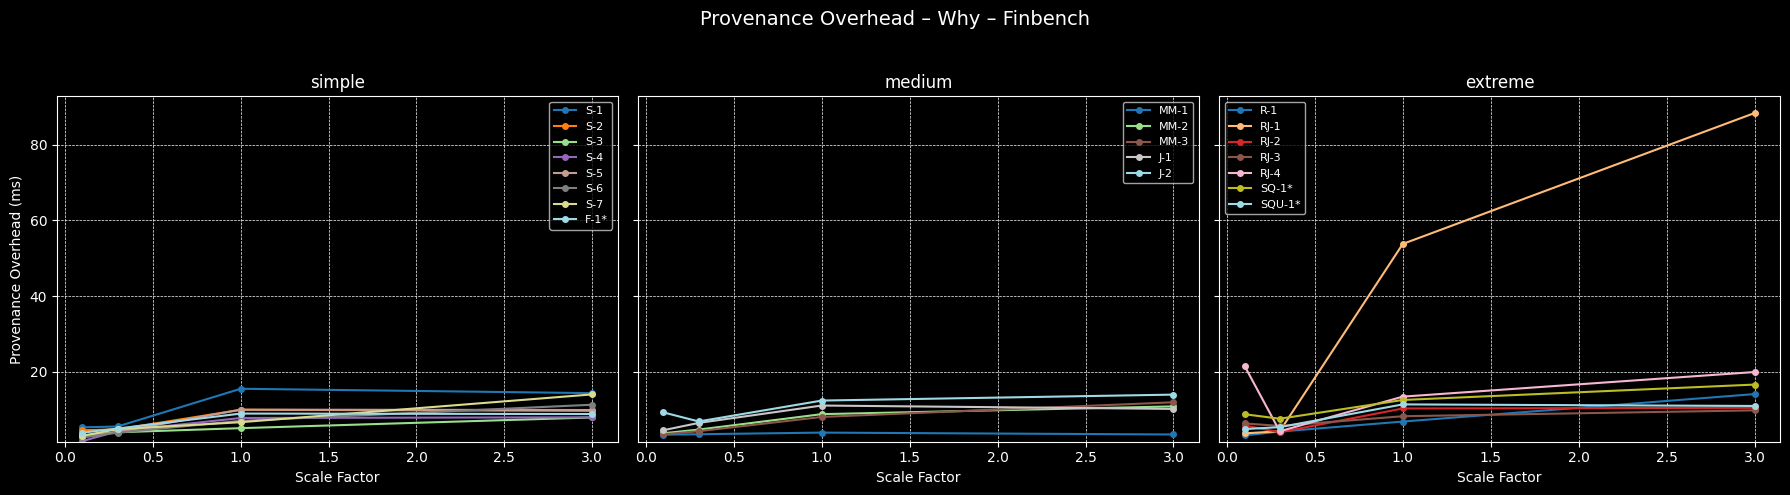

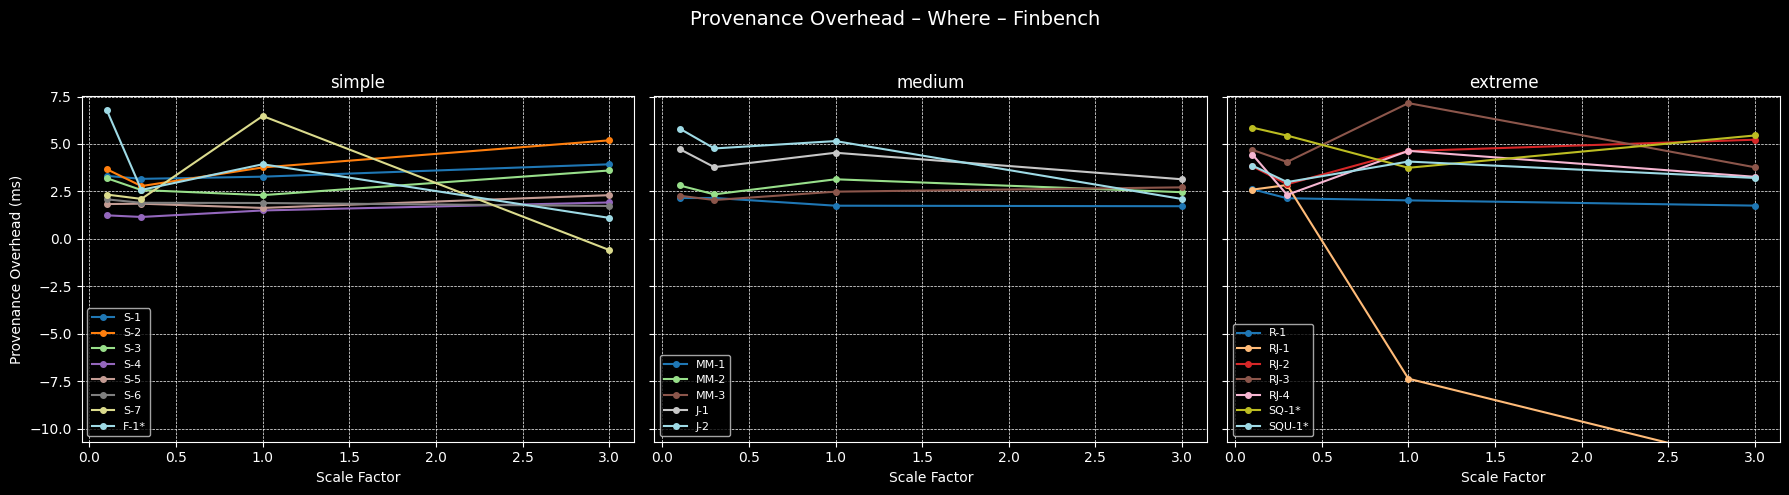

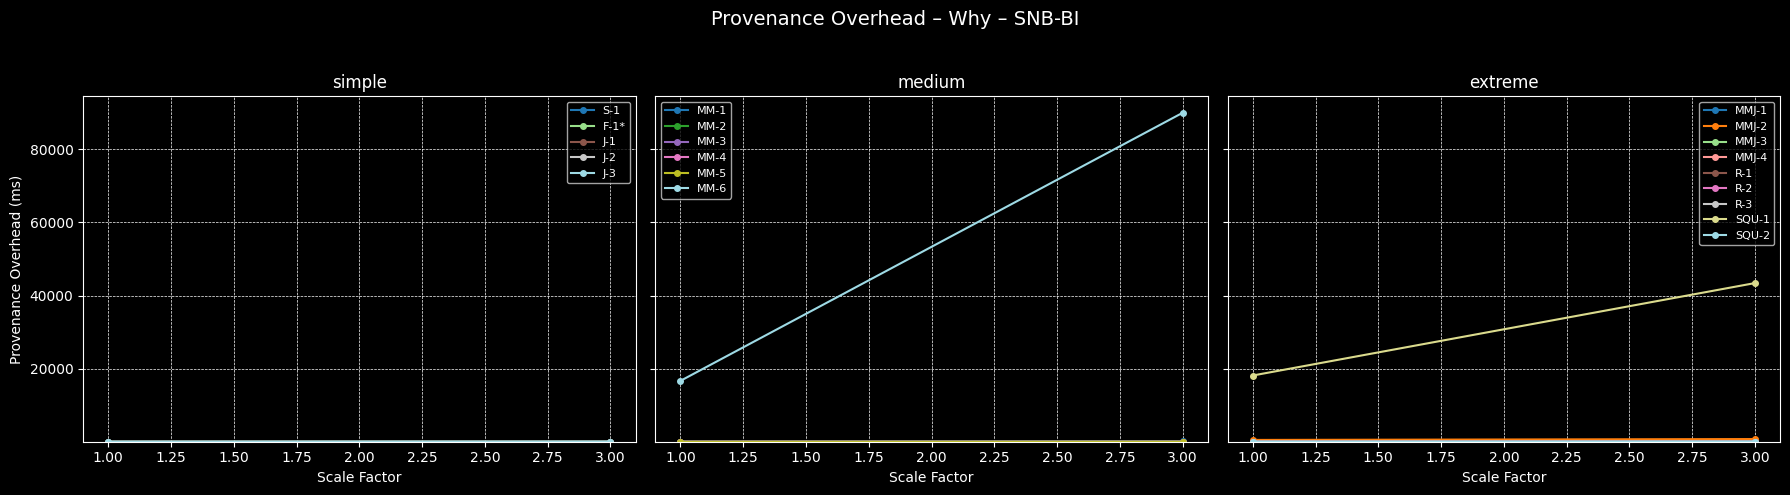

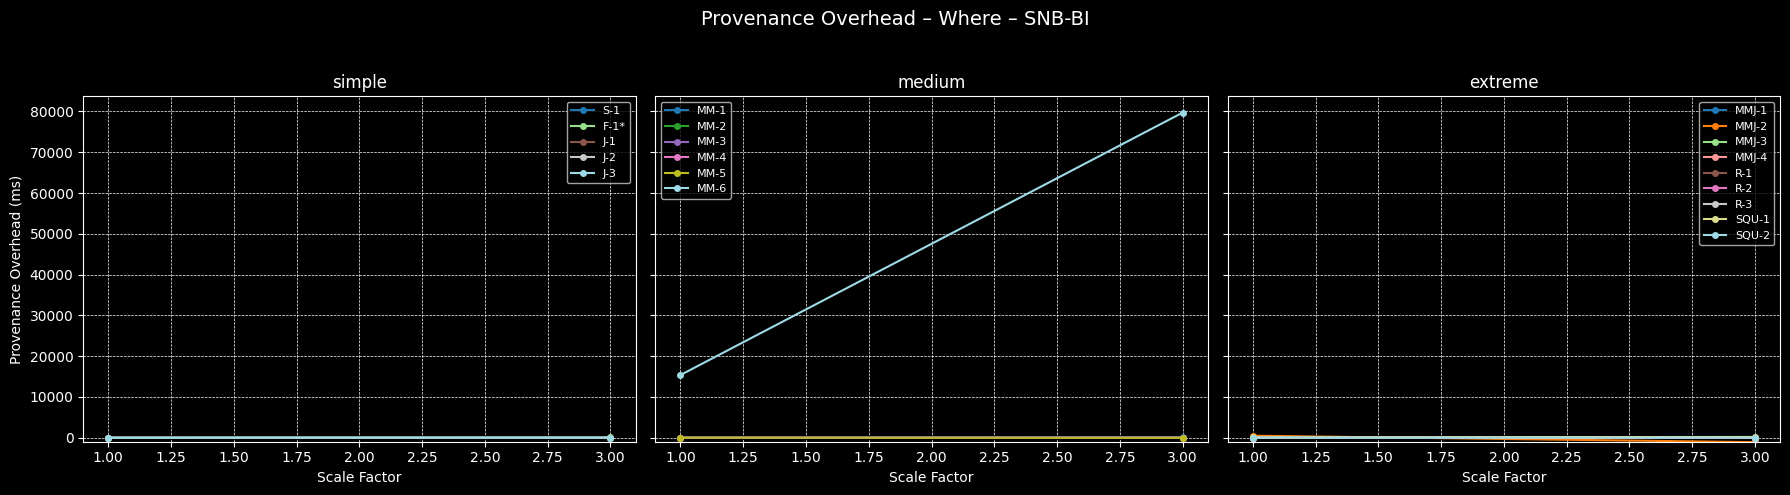

In [13]:
files = [
    "2026-02-10_finbench_0.1_latency.csv",
    "2026-02-10_finbench_0.3_latency.csv",
    "2026-02-09_finbench_1_latency.csv",
    "2026-02-09_finbench_3_latency.csv",
    "2026-02-09_snb_1_latency.csv",
    "2026-02-10_snb_3_latency.csv"
]

finbench_query_name = {
    1 : 'RJ-1',
    2: 'RJ-2',
    3: 'J-1',
    4: 'RJ-3',
    5: 'S-1',
    6: 'S-2',
    7: 'RJ-4',
    8: 'J-2',
    9: 'R-1',
    10: 'MM-1',
    11: 'S-3',
    12: 'S-4',
    13: 'MM-2',
    14: 'MM-3',
    15: 'S-5',
    16: 'S-6',
    17: 'S-7',
    18: 'F-1*',
    19: 'SQ-1*',
    20:'SQU-1*'
}

snb_query_name = {
    1 : 'MM-1',
    2: 'MM-2',
    3: 'R-1',
    4: 'SQU-1',
    5: 'MM-3',
    6: 'MM-4',
    7: 'J-1',
    8: 'MM-5',
    9: 'R-2',
    10: 'MMJ-1',
    11: 'MMJ-2',
    12: 'R-3',
    13: 'MM-6',
    14: 'MMJ-3',
    15: 'SQU-2',
    16: 'MMJ-4',
    17: 'S-1',
    18: 'J-2',
    19: 'J-3',
    20: 'F-1*'
}

snb_custom_order = ['S-1','F-1*','J-1','J-2','J-3','MM-1','MM-2','MM-3',
                    'MM-4','MM-5','MM-6','MMJ-1','MMJ-2','MMJ-3','MMJ-4','R-1','R-2','R-3','SQU-1','SQU-2']
finbench_custom_order = ['S-1','S-2','S-3','S-4','S-5','S-6','S-7', 'F-1*',
                         'MM-1','MM-2','MM-3','J-1','J-2','R-1','RJ-1','RJ-2','RJ-3','RJ-4','SQ-1*','SQU-1*']

finbench_query_groups = {
    "simple":['S-1','S-2','S-3','S-4','S-5','S-6','S-7', 'F-1*'] ,
    "medium":['MM-1','MM-2','MM-3','J-1','J-2'],
    "extreme" : ['R-1','RJ-1','RJ-2','RJ-3','RJ-4','SQ-1*','SQU-1*']
}

snb_query_groups = {
    "simple":['S-1','F-1*','J-1','J-2','J-3'] ,
    "medium":['MM-1','MM-2','MM-3',
              'MM-4','MM-5','MM-6'],
    "extreme" : ['MMJ-1','MMJ-2','MMJ-3','MMJ-4','R-1','R-2','R-3','SQU-1','SQU-2']
}

all_query_groups = {
    "Finbench": finbench_query_groups,
    "SNB-BI": snb_query_groups
}

custom_orders = {
    "Finbench": finbench_custom_order,
    "SNB-BI": snb_custom_order,
}

dataset_mapping = {
    "finbench": "Finbench",
    "snb": "SNB-BI"
}

ORIG_COLOR = "#1f77b4"
PROV_COLOR = "#ff7f0e"
DIFF_COLOR = "#d62728"  # Color for the difference

prov_order = ["Why", "Where"]
legend = {
    "Why": True,
    "Where": False
}

df = pd.concat([pd.read_csv(os.path.join("result/metrics/run_1", f)) for f in files], ignore_index=True)


df["query_type"] = df["query"].str.extract(r'^(prov|orig)')
df["query_id"] = df["query"].str.extract(r'^(?:prov|orig)_(?:finbench|snb)-([\d.]+)_')

# Keep only integers or decimals ending in .3
df = df[df["query_id"].str.match(r"^\d+$|^\d+\.3$")]

# Rename .3 queries to integer part
df["query_id"] = df["query_id"].str.replace(r"\.3$", "", regex=True)
df["query_id"] = df["query_id"].astype(int)

df["query_name"] = None

df.loc[df["dataset"] == "finbench", "query_name"] = (
    df.loc[df["dataset"] == "finbench", "query_id"].map(finbench_query_name)
)

df.loc[df["dataset"] == "snb", "query_name"] = (
    df.loc[df["dataset"] == "snb", "query_id"].map(snb_query_name)
)

df["dataset"] = df["dataset"].map(dataset_mapping).fillna(df["dataset"])

agg2 = (
    df.groupby(["provModel", "dataset","scaleFactor", "query_name", "query_type", "parameter"], as_index=False)
    .agg(mean_exec_time=("mean", "mean"))
)

agg = (
    agg2.groupby(
        ["provModel", "dataset", "scaleFactor", "query_name", "query_type"],
        as_index=False
    )
    .agg(mean_exec_time=("mean_exec_time", "mean"))
)
def per_dataset_overhead_line(dataset_name):
    """
    Plots provenance overhead (prov - orig) per query_name,
    split into 3 groups using all_query_groups map,
    with each query line in a different color.
    """
    query_groups = all_query_groups[dataset_name]

    for prov_model in prov_order:
        if prov_model not in agg["provModel"].values:
            continue  # skip if this prov_model is not in the data

        # Filter by prov_model and dataset
        sub_model = agg[(agg["provModel"] == prov_model) & (agg["dataset"] == dataset_name)].copy()

        # Determine y-axis limits
        all_vals = sub_model["mean_exec_time"]
        # Y_MIN = max((all_vals[all_vals > 0].min() * 0.9), 1e-3)  # avoid log(0)
        # Y_MAX = all_vals.max()*1.05
        # Compute overhead first

        scale_factors = sorted(sub_model["scaleFactor"].unique())
        n_groups = len(query_groups)

        fig, axes = plt.subplots(1, n_groups, figsize=(6*n_groups, 5), sharey=True)
        if n_groups == 1:
            axes = [axes]

        for i, (group_name, queries) in enumerate(query_groups.items()):

            sub_model_overhead = sub_model.pivot_table(
                index=['scaleFactor', 'query_name'],
                columns='query_type',
                values='mean_exec_time'
            )
            sub_model_overhead['overhead'] = sub_model_overhead['prov'] - sub_model_overhead['orig']

            # Determine y-axis limits from overhead
            Y_MIN = sub_model_overhead['overhead'].min() * 0.9
            Y_MAX = sub_model_overhead['overhead'].max() * 1.05

            ax = axes[i]
            queries = [q for q in queries if q in sub_model["query_name"].values]

            # Get a color map for this group
            colors = plt.colormaps['tab20'].resampled(len(queries)) # 'tab20' has 20 distinct colors

            for j, query in enumerate(queries):
                query_data = sub_model[sub_model["query_name"] == query].set_index("scaleFactor")

                # Extract orig and prov times
                orig = query_data[query_data["query_type"]=="orig"]["mean_exec_time"].reindex(scale_factors)
                prov = query_data[query_data["query_type"]=="prov"]["mean_exec_time"].reindex(scale_factors)

                # Compute overhead
                overhead = prov - orig

                # Plot line with a unique color
                ax.plot(scale_factors, overhead, marker='o', linestyle='-',
                        label=query, markersize=4, color=colors(j))

            # ax.set_yscale("log")
            ax.set_ylim(Y_MIN, Y_MAX)
            ax.set_xlabel("Scale Factor")
            if i == 0:
                ax.set_ylabel("Provenance Overhead (ms)")
            ax.set_title(group_name)
            ax.grid(True, which="both", ls="--", lw=0.5)
            ax.legend(fontsize=8, ncol=1)

        fig.suptitle(f"Provenance Overhead – {prov_model} – {dataset_name}", fontsize=14)
        plt.tight_layout(rect=[0,0,1,0.95])

        os.makedirs("./result/new_plots", exist_ok=True)
        # filename = f"./result/new_plots/{dataset_name}_overhead_{prov_model}-line-split.png"
        # plt.savefig(filename, dpi=300, bbox_inches='tight')
        # print(f"Saved overhead line chart to {filename}")
        plt.show()

# Run for both datasets
per_dataset_overhead_line("Finbench")
per_dataset_overhead_line("SNB-BI")



Saved plot to ./result/new_plots/Major-R-1_Why.png


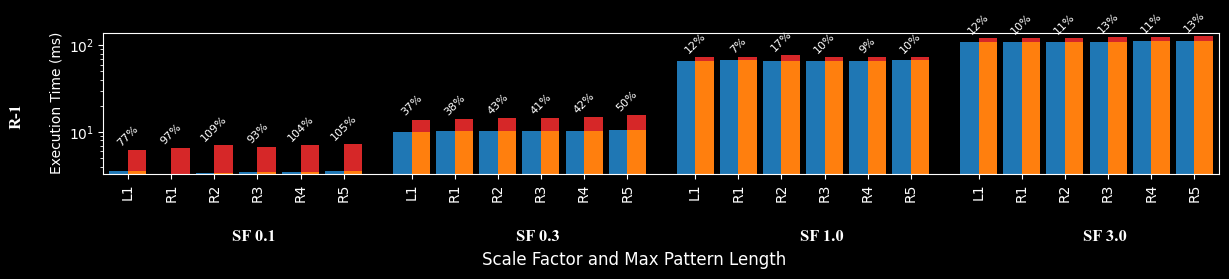

Saved plot to ./result/new_plots/Major-RJ-1_Why.png


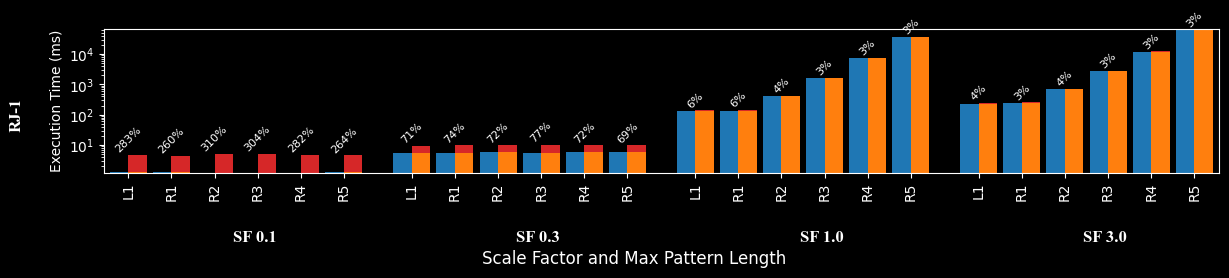

Saved plot to ./result/new_plots/Major-RJ-2_Why.png


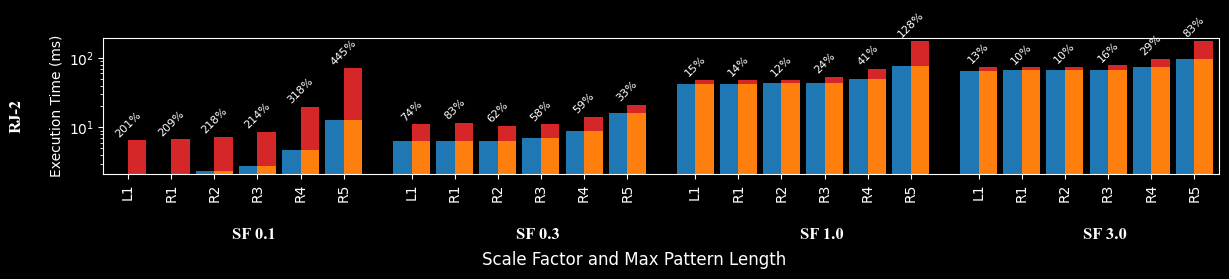

Saved plot to ./result/new_plots/Major-RJ-3_Why.png


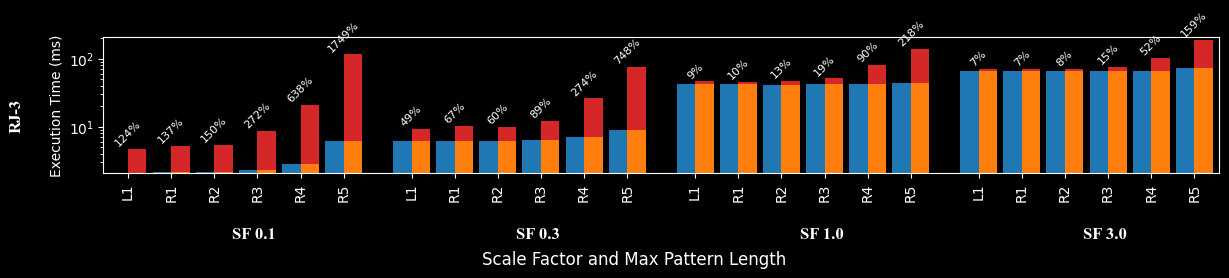

Saved plot to ./result/new_plots/Major-RJ-4_Why.png


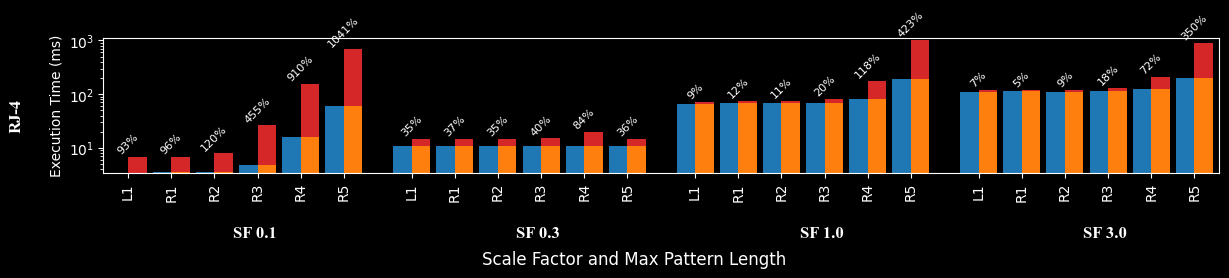

Saved plot to ./result/new_plots/Major-R-1_Where.png


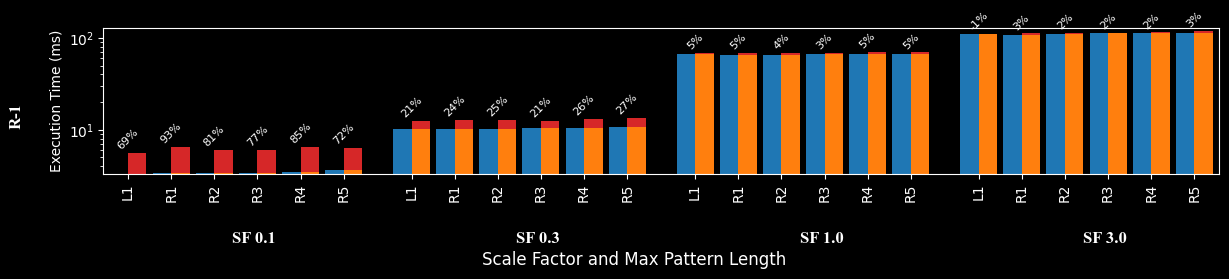

Saved plot to ./result/new_plots/Major-RJ-1_Where.png


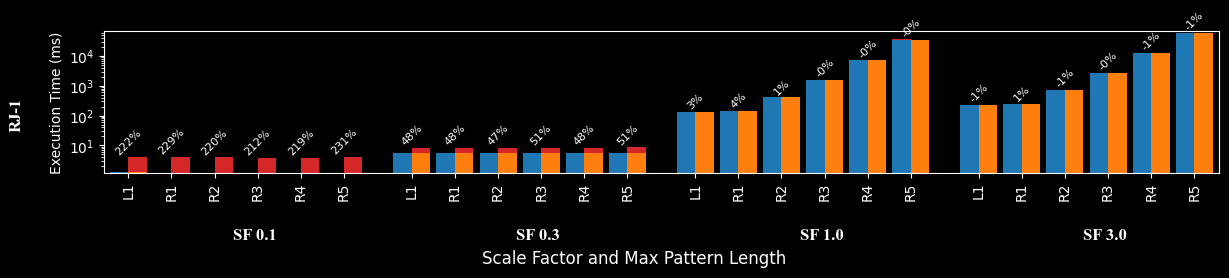

Saved plot to ./result/new_plots/Major-RJ-2_Where.png


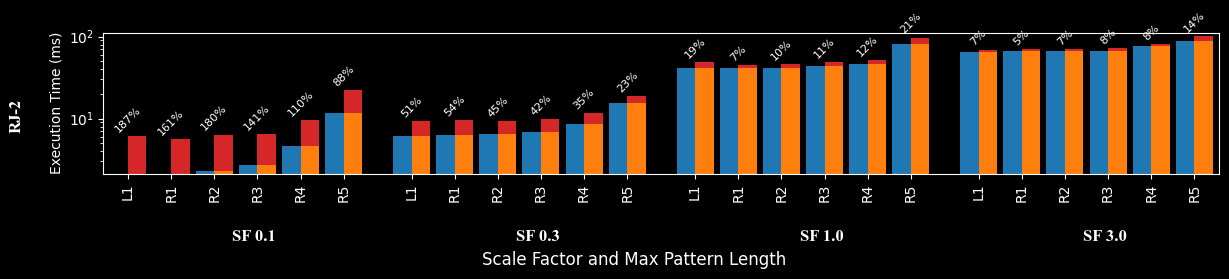

Saved plot to ./result/new_plots/Major-RJ-3_Where.png


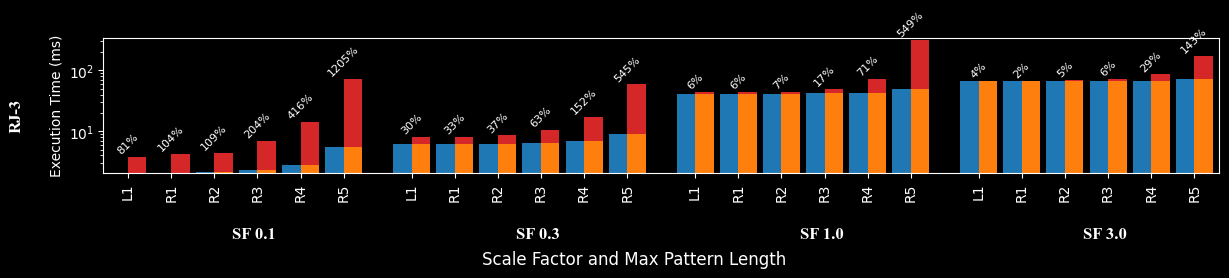

Saved plot to ./result/new_plots/Major-RJ-4_Where.png


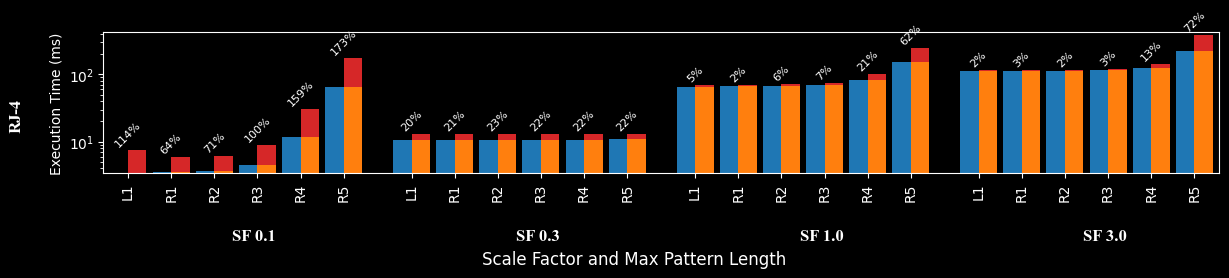

In [15]:
LINE_ORIG_COLOR = "#00CED1"  # Bright cyan
LINE_PROV_COLOR = "#FF00FF"  # Bright magenta
ORIG_COLOR = "#1f77b4"
PROV_COLOR = "#ff7f0e"
DIFF_COLOR = "#d62728"  # Color for the difference

finbench_query_name = {
    1 : 'RJ-1',
    2: 'RJ-2',
    3: 'J-1',
    4: 'RJ-3',
    5: 'S-1',
    6: 'S-2',
    7: 'RJ-4',
    8: 'J-2',
    9: 'R-1',
    10: 'MM-1',
    11: 'S-3',
    12: 'S-4',
    13: 'MM-2',
    14: 'MM-3',
    15: 'S-5',
    16: 'S-6',
    17: 'S-7',
    18: 'F-1*',
    19: 'SQ-1*',
    20:'SQU-1*'
}

finbench_map = {
    ".1.1" : "L1",
    ".1" : "R1",
    ".2" :"R2",
    ".3" : "R3",
    ".4" :"R4",
    ".5":"R5"
}

files = [
    "2026-02-10_finbench_0.1_latency.csv",
    "2026-02-10_finbench_0.3_latency.csv",
    "2026-02-09_finbench_1_latency.csv",
    "2026-02-09_finbench_3_latency.csv",
    "2026-02-09_snb_1_latency.csv",
    "2026-02-10_snb_3_latency.csv"
]

dataset_mapping = {
    "finbench": "Finbench",
    "snb": "SNB-BI"
}

prov_order = ["Why", "Where"]
legend = {
    "Why": True,
    "Where": False
}

def map_query_name(qid):
    for suffix, label in finbench_map.items():
        if qid.endswith(suffix):
            return label
    return qid  # fallback if no match

df = pd.concat([pd.read_csv(os.path.join("result/metrics/run_1", f)) for f in files], ignore_index=True)
df["query_type"] = df["query"].str.extract(r'^(prov|orig)')
df["query_id"] = df["query"].str.extract(r'^(?:prov|orig)_(?:finbench|snb)-([\d.]+)_') # Keep only decimal queries
df = df[df["query_id"].str.contains(r'\d+\.\d')].copy()
df["query_major"] = df["query_id"].str.extract(r'^(\d+)')[0].astype(int)
df["query_major"] = df["query_major"].map(finbench_query_name)
df["query_name"] = df["query_id"].apply(map_query_name)
df["dataset"] = df["dataset"].map(dataset_mapping).fillna(df["dataset"])
agg2 = (
    df.groupby(
        ["provModel", "dataset", "scaleFactor", "query_major", "query_name", "query_type", "parameter"], as_index=False )
    .agg(mean_exec_time=("mean", "mean")) )

agg = (
    agg2.groupby(
        ["provModel", "dataset", "scaleFactor", "query_major", "query_name", "query_type"],
        as_index=False
    )
    .agg(mean_exec_time=("mean_exec_time", "mean"))
)
## ================= Plot execution times as bar charts with increment =================
# First, compute the increment (prov - orig)
agg_pivot = agg.pivot_table(
    index=["provModel", "dataset", "scaleFactor", "query_major", "query_name"],
    columns="query_type",
    values="mean_exec_time"
).reset_index()
agg_pivot["increment"] = agg_pivot["prov"] - agg_pivot["orig"]

for prov_model in prov_order:
    if prov_model not in agg_pivot["provModel"].values:
        continue

    sub_model = agg_pivot[agg_pivot["provModel"] == prov_model]

    for major in sorted(sub_model["query_major"].unique()):
        sub_major = sub_model[sub_model["query_major"] == major].copy()

        fig, ax = plt.subplots(figsize=(12, 3))

        # ===== spacing controls =====
        bar_width = 0.15
        query_gap = 0.05
        sf_gap = 0.2

        cursor = 0
        xticks = []
        xticklabels = []
        sf_centers = []

        all_vals = []

        # ===== TOP LEVEL: SCALE FACTOR =====
        for sf in sorted(sub_major["scaleFactor"].unique()):
            sub_sf = sub_major[sub_major["scaleFactor"] == sf]
            start_sf = cursor

            # ===== SECOND LEVEL: QUERY ID =====
            for _, row in sub_sf.sort_values("query_name").iterrows():
                q = row["query_name"]
                o = row["orig"]
                p = row["prov"]

                # left = orig, right = prov
                x_orig = cursor - bar_width / 2
                x_prov = cursor + bar_width / 2

                # base bars
                ax.bar(x_orig, o, bar_width, color=ORIG_COLOR)
                ax.bar(x_prov, p, bar_width, color=PROV_COLOR)

                # diff overlay
                if p > o:
                    ax.bar(x_prov, p - o, bar_width, bottom=o, color=DIFF_COLOR)
                else:
                    ax.bar(x_orig, o - p, bar_width, bottom=p, color=DIFF_COLOR)

                # % annotation
                diff_pct = (p - o) / o * 100
                ax.text(
                    cursor,
                    max(o, p) * 1.05,
                    f"{diff_pct:.0f}%",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    rotation=45,
                )

                xticks.append(cursor)
                xticklabels.append(q)

                all_vals.extend([o, p])

                cursor += bar_width * 2 + query_gap

            end_sf = cursor - query_gap
            sf_centers.append((start_sf + end_sf) / 2)
            cursor += sf_gap

        # ===== Axis formatting =====
        ax.set_yscale("log")
        ax.set_ylabel("Execution Time (ms)")

        ymin = min(v for v in all_vals if v > 0)
        ymax = max(all_vals) * 1.1
        ax.set_ylim(ymin, ymax)
        ax.set_xlim(min(xticks) - 0.2, max(xticks) + 0.2)

        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels, rotation=90)

        # ===== Legend =====
        if legend[prov_model]:
            handles = [
                mpatches.Patch(color=ORIG_COLOR, label="Original"),
                mpatches.Patch(color=PROV_COLOR, label="Provenance"),
                mpatches.Patch(color=DIFF_COLOR, label="Difference"),
            ]


        # ===== TOP LEVEL LABELS (Scale Factors) =====
        for center, sf in zip(
                sf_centers, sorted(sub_major["scaleFactor"].unique())
        ):
            ax.text(
                center,
                -0.4,
                f"SF {sf}",
                transform=ax.get_xaxis_transform(),
                ha="center",
                va="top",
                fontsize=12,
                fontweight="bold",
                fontname="Times New Roman",
            )

        fig.text(
            -0.02,              # horizontal center
            0.6,             # y position below the axes (negative)
            f"{major}",    # text
            fontsize=12,
            ha='left',      # horizontal alignment
            va='center'  ,
            rotation=90,
            fontweight="bold",
            fontname="Times New Roman"
        )
        # ax.legend(
        #     handles=handles,
        #     frameon=False,
        #     ncol=3,
        #     loc="upper center",
        #     bbox_to_anchor=(0.5, 1.35)
        # )
        fig.text(
            0.5,              # horizontal center
            0.15,             # y position below the axes (negative)
            f"Scale Factor and Max Pattern Length",    # text
            fontsize=12,
            ha='center',      # horizontal alignment
            va='top'       # vertical alignment relative to the y position,

        )

        # fig.suptitle(f"{prov_model} – Major Query {major}", fontsize=14)
        fig.tight_layout()

        # ===== Save =====
        os.makedirs("./result/new_plots", exist_ok=True)
        filename = f"./result/new_plots/Major-{major}_{prov_model}.png"
        fig.savefig(filename, dpi=300, bbox_inches="tight")
        print(f"Saved plot to {filename}")
        plt.show()




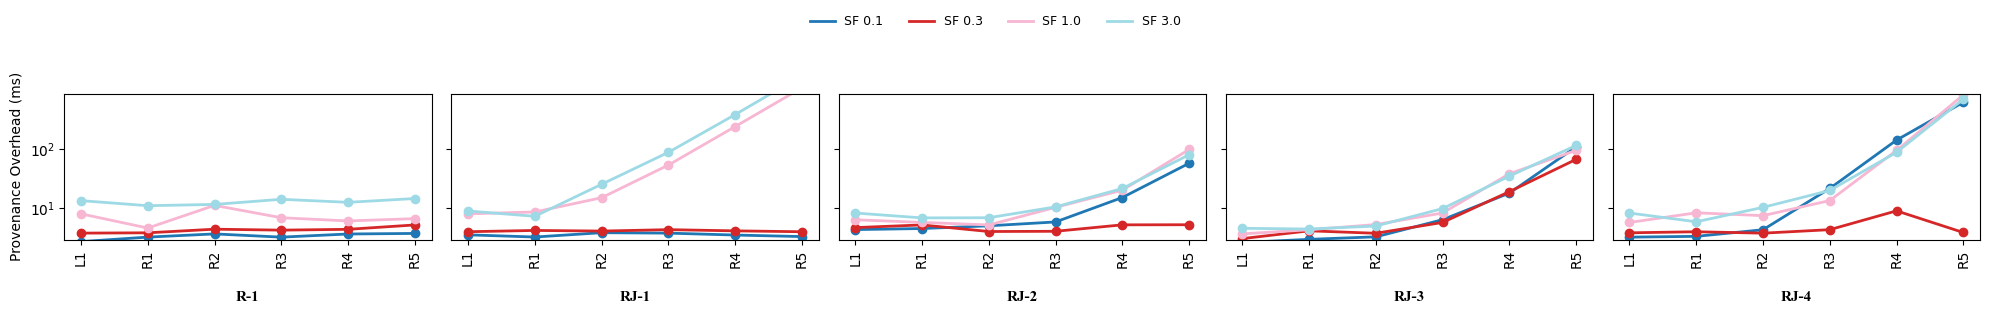

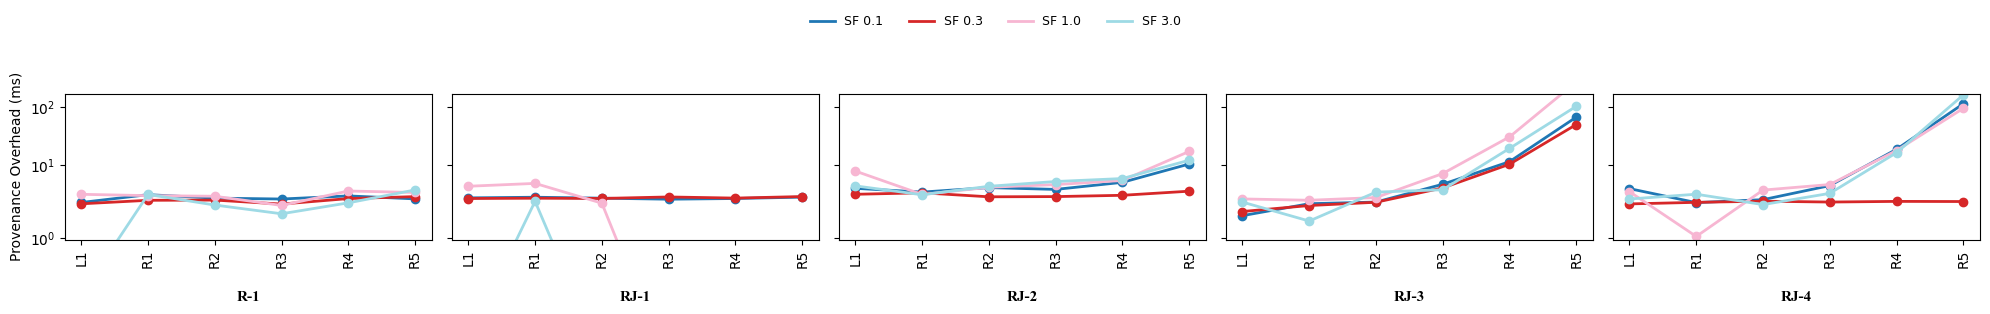

In [60]:
# ------------------ Plot ------------------
for prov_model in prov_order:
    sub_model = agg_pivot[agg_pivot["provModel"] == prov_model]
    if sub_model.empty:
        continue

    majors = sorted(sub_model["query_major"].unique())
    n_major = len(majors)

    fig, axes = plt.subplots(1, n_major, figsize=(4 * n_major, 3), sharey=True)
    if n_major == 1:
        axes = [axes]

    sf_list = sorted(sub_model["scaleFactor"].unique())
    colors = plt.colormaps['tab20'].resampled(len(sf_list))  # Color per scale factor

    for ax, major in zip(axes, majors):
        sub_major = sub_model[sub_model["query_major"] == major]

        query_order = sorted(sub_major["query_name"].unique())
        x = np.arange(len(query_order))

        for j, sf in enumerate(sf_list):
            sub_sf = sub_major[sub_major["scaleFactor"] == sf].set_index("query_name").loc[query_order]
            overhead = sub_sf["overhead"].values

            ax.plot(
                x,
                overhead,
                linewidth=2,
                color=colors(j),
                linestyle="-",
                marker='o',
                label=f"SF {sf}" if major == majors[0] else None  # legend only for first subplot
            )

        ax.text(
            0.5,
            -0.35,
            major,
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=11,
            fontweight="bold",
            fontname="Times New Roman",
        )

        ax.set_xticks(x)
        ax.set_xticklabels(query_order, rotation=90)
        ax.set_yscale("log")

        # Y-axis limits from overhead values
        vals = sub_major["overhead"].values
        ymin = max(vals[vals>0].min()*0.9, 1e-3)
        ymax = vals.max()*1.05
        ax.set_ylim(ymin, ymax)

    axes[0].set_ylabel("Provenance Overhead (ms)")

    # Legend for scale factor colors
    sf_handles = [
        Line2D([0], [0], color=colors(j), lw=2, linestyle="-", label=f"SF {sf}")
        for j, sf in enumerate(sf_list)
    ]

    fig.legend(
        handles=sf_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.15),
        ncol=4,
        frameon=False,
        fontsize=9
    )

    fig.tight_layout(rect=[0, 0, 1, 0.9])
    # os.makedirs("./result/new_plots", exist_ok=True)
    # filename = f"./result/new_plots/{prov_model}_all_majors_overhead.png"
    # fig.savefig(filename, dpi=300, bbox_inches="tight")
    # print(f"Saved plot to {filename}")
    plt.show()


Saved plot to ./result/new_plots/Where-resultSize.png


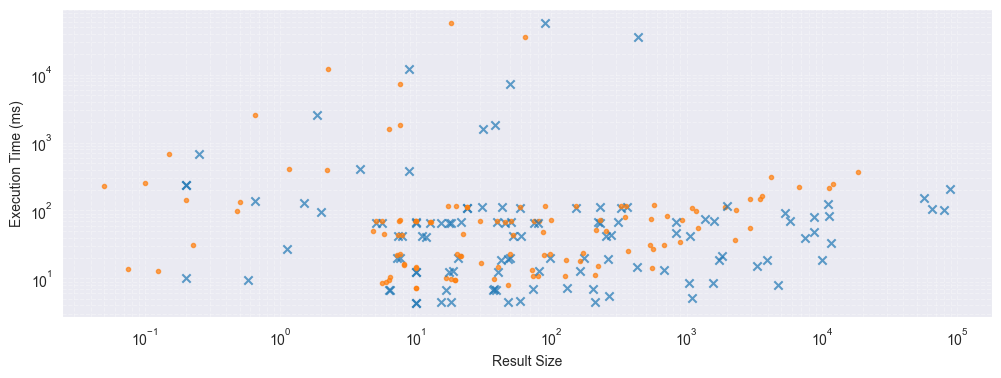

In [221]:
df = pd.concat([pd.read_csv(os.path.join("result/metrics", f)) for f in files], ignore_index=True)
df["query_type"] = df["query"].str.extract(r'^(prov|orig)')
df["query_id"] = df["query"].str.extract(r'^(?:prov|orig)_(?:finbench|snb)-([\d.]+)_') # Keep only decimal queries
df = df[df["query_id"].str.contains(r'\d+\.\d')].copy()
df["query_major"] = df["query_id"].str.extract(r'^(\d+)')[0].astype(int)
df["query_major"] = df["query_major"].map(finbench_query_name)
df["query_name"] = df["query_id"].apply(map_query_name)
df["dataset"] = df["dataset"].map(dataset_mapping).fillna(df["dataset"])
agg2 = (
    df.groupby(
        ["provModel", "dataset", "scaleFactor", "query_major", "query_name", "query_type", "parameter"], as_index=False )
    .agg(mean_exec_time=("mean", "mean"), mean_result_size=("resultSize", "mean") ) )

agg = (
    agg2.groupby(
        ["provModel", "dataset", "scaleFactor", "query_major", "query_name", "query_type"],
        as_index=False
    )
    .agg(mean_exec_time=("mean_exec_time", "mean"), resultSize=("mean_result_size", "mean"))
)

scatter_df = agg

fig, ax = plt.subplots(figsize=(12, 4))

for sf in sorted(scatter_df["scaleFactor"].unique()):
    sub_sf = scatter_df[scatter_df["scaleFactor"] == sf]
    sub_sf = sub_sf[sub_sf["provModel"] == "Where"]

    # ----- Original -----
    orig = sub_sf[sub_sf["query_type"] == "orig"]
    ax.scatter(
        orig["resultSize"],
        orig["mean_exec_time"],
        marker="x",
        color=ORIG_COLOR,
        alpha=0.7,
    )

    # ----- Provenance -----
    prov = sub_sf[sub_sf["query_type"] == "prov"]
    ax.scatter(
        prov["resultSize"],
        prov["mean_exec_time"],
        marker=".",
        color=PROV_COLOR,
        alpha=0.7,
    )

# ===== Axis formatting =====
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Result Size")
ax.set_ylabel("Execution Time (ms)")

ax.grid(True, which="both", linestyle="--", alpha=0.3)

os.makedirs("./result/new_plots", exist_ok=True)
filename = f"./result/new_plots/Where-resultSize.png"
fig.savefig(filename, dpi=300, bbox_inches="tight")
print(f"Saved plot to {filename}")
plt.show()


In [16]:
file_name = '2026-01-21_6_latency.csv'

all_data = []


df = pd.read_csv(os.path.join('./result/metrics/run_1',file_name))
provModels = df['provModel'].unique().tolist()
datasets = df['dataset'].unique().tolist()

# provModels = df['provModel'].unique().tolist()
# datasets = df['dataset'].unique().tolist()

for provModel in provModels:
    all_data = {
    }
    for dataset in datasets:
        scale_factors = [0.1]
        # scale_factors = df['scaleFactor'].unique().tolist()
        sf_data=[]
        for sf in scale_factors:
            dt_sf_prov = df[ (df['provModel']== provModel) & (df['dataset'] == dataset) & (df['scaleFactor'] == sf)][['query','mean']]

            orig = dt_sf_prov[dt_sf_prov['query'].str.startswith('orig_')].set_index('query')
            prov = dt_sf_prov[dt_sf_prov['query'].str.startswith('prov_')].set_index('query')

            orig.index = orig.index.str.replace('orig_', '')
            prov.index = prov.index.str.replace('prov_', '')

            comparison = orig.join(prov, lsuffix='_orig', rsuffix='_prov')
            sf_data.append((sf,comparison))
        all_data[dataset]=sf_data

    fig, ax = plt.subplots(figsize=(14, 6))

    bar_width = 0.35
    gap_queries = 0.2
    gap_sf = 1.0
    gap_dataset = 2.0

    x_positions = []
    query_labels = []

    current_x = 0

    sf_centers = []
    dataset_centers = []

    for dataset_name, sf_list in all_data.items():
        dataset_start = current_x

        for sf_idx, (sf, comparison) in enumerate(sf_list):
            n_queries = len(comparison)
            x_inner = np.arange(current_x, current_x + n_queries)

            # Store query ticks
            x_positions.extend(x_inner)
            query_labels.extend(comparison.index)

            # Plot bars
            ax.bar(x_inner - bar_width / 2, comparison['mean_orig'],
                   width=bar_width,
                   label='orig' if current_x == 0 else "")
            ax.bar(x_inner + bar_width / 2, comparison['mean_prov'],
                   width=bar_width,
                   label='prov' if current_x == 0 else "")

            # Scale factor center
            sf_centers.append((x_inner.mean(), sf))

            current_x += n_queries + gap_sf

        dataset_end = current_x - gap_sf
        dataset_centers.append(((dataset_start + dataset_end) / 2, dataset_name))
        current_x += gap_dataset

    # ---- Query ticks (level 1)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(query_labels, rotation=45, ha='right')

    ax.set_ylabel('Mean Value')
    ax.set_title(f"{provModel} Provenance : Original vs Provenance Query Latencies")

    # ---- Scale factor labels (level 2)
    ymin, ymax = ax.get_ylim()
    sf_y = ymin - (ymax - ymin) * 0.08

    for x, sf in sf_centers:
        ax.text(x, sf_y, f'SF {sf}', ha='center', va='top', fontsize=10)

    # ---- Dataset labels (level 3)
    dataset_y = ymin - (ymax - ymin) * 0.15

    for x, name in dataset_centers:
        ax.text(x, dataset_y, name, ha='center', va='top',
                fontsize=11, fontweight='bold')

    # ---- Layout
    plt.subplots_adjust(bottom=0.30)
    ax.legend()
    plt.show()




FileNotFoundError: [Errno 2] No such file or directory: './result/metrics/run_1/2026-01-21_6_latency.csv'

In [8]:

file_name = '2026-01-21_1_latency.csv'

def query_number(qid):
    """
    Extract numeric suffix from query id, e.g. finbench-15 -> 15
    """
    m = re.search(r"-(\d+(?:\.\d+)?)$", qid)
    return float(m.group(1)) if m else float("inf")


def make_tables(filename):
    groups = defaultdict(lambda: defaultdict(dict))

    with open(os.path.join('./result/metrics/',file_name), newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            dataset = row["dataset"]
            scale = row["scaleFactor"]
            prov_model = row["provModel"]
            query = row["query"]
            mean = float(row["mean"])
            if "hitRate" in row.keys():
                hit_rate = float(row["hitRate"])
            else:
                hit_rate = "N/A"

            if query.startswith("orig_"):
                qid = query.replace("orig_", "")
                groups[(dataset, scale, prov_model)][qid]["orig"] = mean
                groups[(dataset, scale, prov_model)][qid]["hit_rate"] = hit_rate
            elif query.startswith("prov_"):
                qid = query.replace("prov_", "")
                groups[(dataset, scale, prov_model)][qid]["prov"] = mean
                groups[(dataset, scale, prov_model)][qid]["hit_rate"] = hit_rate

    # Print tables sorted by query number
    for (dataset, scale, prov_model), queries in sorted(groups.items()):
        print(f"\nDataset: {dataset}, ScaleFactor: {scale}, ProvModel: {prov_model}")
        print(f"{'Query':<15} {'Orig Mean':>12} {'Prov Mean':>12} {'Hit Rate':>12} {'% Change':>12}")
        print("-" * 60)

        for qid in sorted(queries.keys(), key=query_number):
            vals = queries[qid]
            orig = vals.get("orig")
            prov = vals.get("prov")
            hitRate = vals.get("hit_rate")

            if orig is not None and prov is not None:
                pct = ((prov - orig) / orig) * 100
                pct_str = f"{pct:.2f}%"
                orig_str = f"{orig:.4f}"
                prov_str = f"{prov:.4f}"
            else:
                pct_str = "N/A"
                orig_str = f"{orig:.4f}" if orig is not None else "N/A"
                prov_str = f"{prov:.4f}" if prov is not None else "N/A"

            print(f"{qid:<15} {orig_str:>12} {prov_str:>12} {hitRate:>12} {pct_str:>12}")

make_tables(file_name)


Dataset: finbench, ScaleFactor: 0.1, ProvModel: How
Query              Orig Mean    Prov Mean     Hit Rate     % Change
------------------------------------------------------------
finbench-1         1056.0716    1076.0884          N/A        1.90%
finbench-2           72.6139     198.3647          N/A      173.18%
finbench-3          149.2435     175.7076          N/A       17.73%
finbench-4          160.7637     303.6370          N/A       88.87%
finbench-5          173.1746     258.5841          N/A       49.32%
finbench-6          160.0881     214.7878          N/A       34.17%
finbench-7          116.8651     549.4201          N/A      370.13%
finbench-8          170.7741     558.6754          N/A      227.14%
finbench-9           84.8842     112.0775          N/A       32.04%
finbench-10          54.5332      73.2104          N/A       34.25%
finbench-11          54.5482      72.9620          N/A       33.76%
finbench-12         150.0343     156.1674          N/A        4.09%
fi

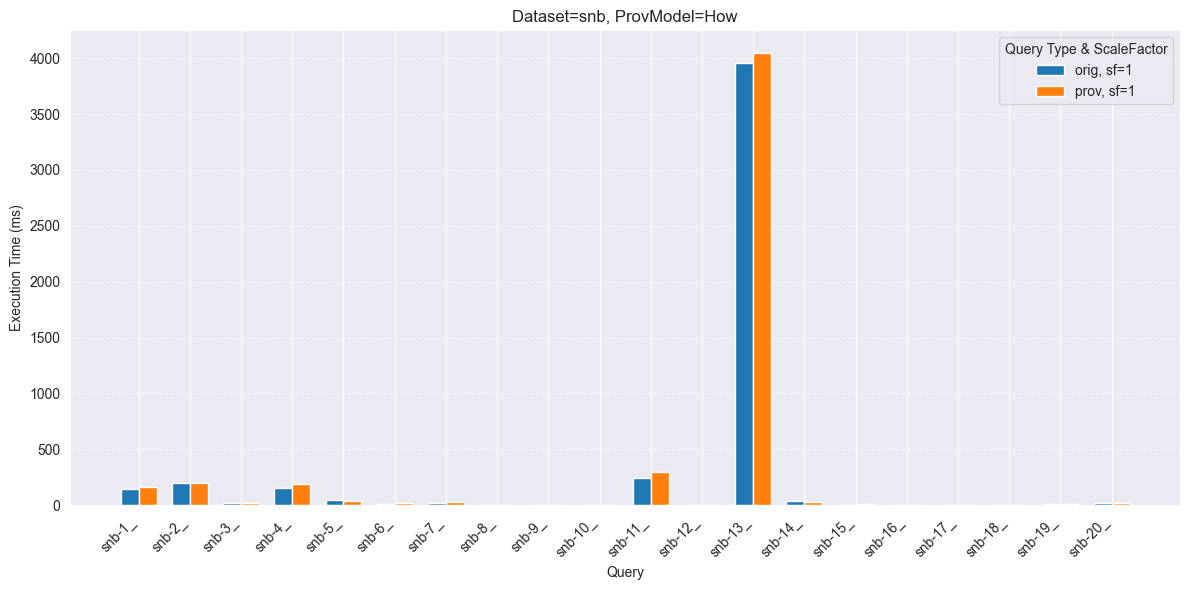

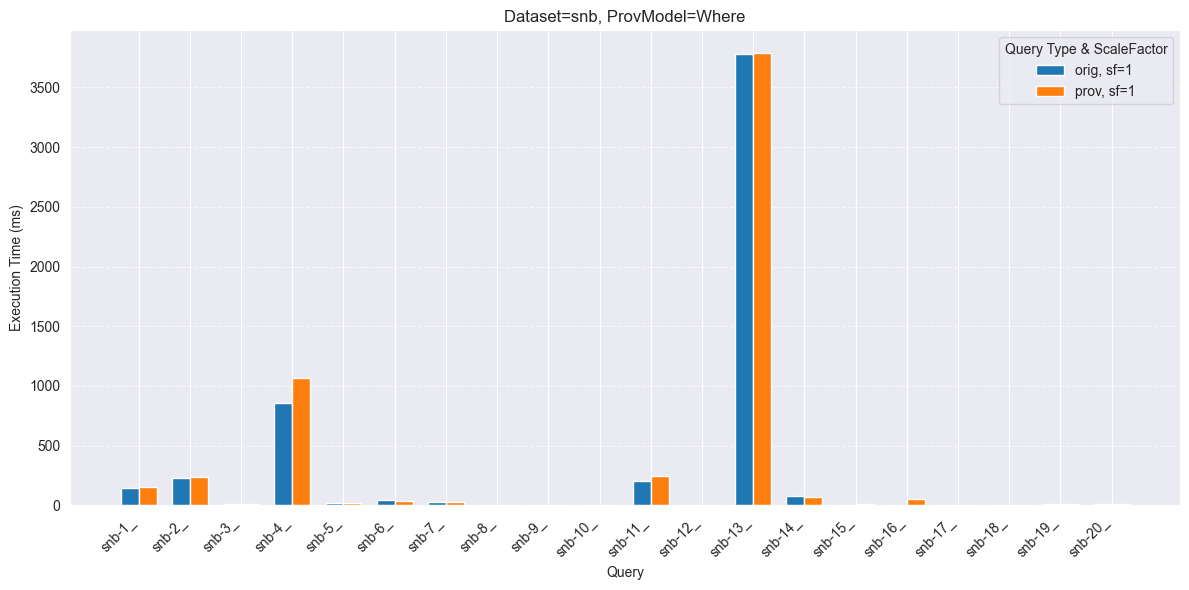

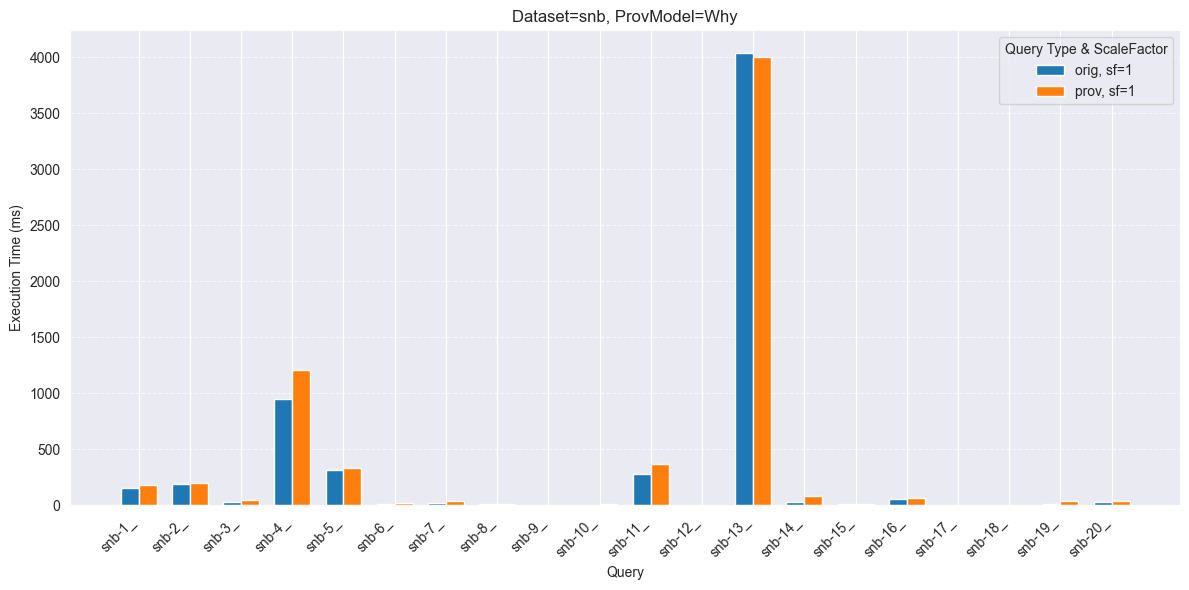

In [108]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import re

# Load CSV
file_name = '2026-01-22_test-snbbi_latency.csv'
df = pd.read_csv(os.path.join('./result/metrics/', file_name))

# Identify query type
df["query_type"] = df["query"].apply(lambda q: "orig" if q.startswith("orig_") else "prov")

# Extract base query
df["base_query"] = df["query"].str.replace(r"^(orig_|prov_)", "", regex=True)
df = df[df["base_query"]!="finbench-7.4_"]

# Apply scaling
df["adjusted_mean"] = df["mean"] * 10
agg = (
    df.groupby(["dataset", "scaleFactor", "provModel", "base_query", "query_type"])
    .agg(total_mean=("adjusted_mean", "sum"))
    .reset_index()
)
agg["total_mean"] /= 100

# Sort by query number
def query_number(q):
    m = re.search(r"-(\d+)", q)
    return int(m.group(1)) if m else float("inf")

agg["query_num"] = agg["base_query"].apply(query_number)
agg = agg.sort_values("query_num")

datasets = agg["dataset"].unique()
prov_models = agg["provModel"].unique()
scale_factors = sorted(agg["scaleFactor"].unique())

for ds in datasets:
    for pm in prov_models:
        subset = agg[(agg["dataset"] == ds) & (agg["provModel"] == pm)]

        plt.figure(figsize=(12,6))

        x_labels = subset["base_query"].unique()
        x = np.arange(len(x_labels))
        n_sf = len(scale_factors)
        width = 0.35 / n_sf  # small enough for orig+prov per scaleFactor

        for i, sf in enumerate(scale_factors):
            sf_data = subset[subset["scaleFactor"] == sf].set_index("base_query").loc[x_labels]

            # Plot orig and prov side by side
            plt.bar(x - width/2 + i*width, sf_data[sf_data["query_type"]=="orig"]["total_mean"],
                    width=width, color="tab:blue", label=f"orig, sf={sf}" if i==0 else "")
            plt.bar(x + width/2 + i*width, sf_data[sf_data["query_type"]=="prov"]["total_mean"],
                    width=width, color="tab:orange", label=f"prov, sf={sf}" if i==0 else "")

        plt.xticks(x, x_labels, rotation=45, ha="right")
        plt.xlabel("Query")
        plt.ylabel("Execution Time (ms)")
        plt.title(f"Dataset={ds}, ProvModel={pm}")
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        # Remove duplicate legend entries
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys(), title="Query Type & ScaleFactor")

        plt.tight_layout()
        plt.show()


In [111]:
file_name = '2026-01-22_test-snbbi_latency.csv'
df = pd.read_csv(os.path.join('./result/metrics/', file_name))

# Identify query type
df["query_type"] = df["query"].apply(lambda q: "orig" if q.startswith("orig_") else "prov")

# Extract base query
df["base_query"] = df["query"].str.replace(r"^(orig_|prov_)", "", regex=True)

param_mean = df.groupby([
    "dataset", "scaleFactor", "provModel",
    "query_type", "base_query", "parameter"
])["resultSize"].mean().reset_index()

dataset_success = (
    param_mean.groupby([
        "dataset", "scaleFactor", "provModel",
        "query_type", "base_query"
    ])
    .apply(lambda g: (g["resultSize"] > 0).mean())
    .reset_index(name="success_ratio")
)

dataset_success[dataset_success["success_ratio"]==0]

/var/folders/ll/x2qgpx8s7nq02qgm1pfftv6w0000gn/T/ipykernel_43334/1483053769.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  param_mean.groupby([


,dataset,scaleFactor,provModel,query_type,base_query,success_ratio
0,snb,1,How,orig,snb-10_,0.0
2,snb,1,How,orig,snb-12_,0.0
4,snb,1,How,orig,snb-14_,0.0
5,snb,1,How,orig,snb-15_,0.0
18,snb,1,How,orig,snb-8_,0.0
20,snb,1,How,prov,snb-10_,0.0
22,snb,1,How,prov,snb-12_,0.0
24,snb,1,How,prov,snb-14_,0.0
25,snb,1,How,prov,snb-15_,0.0
38,snb,1,How,prov,snb-8_,0.0


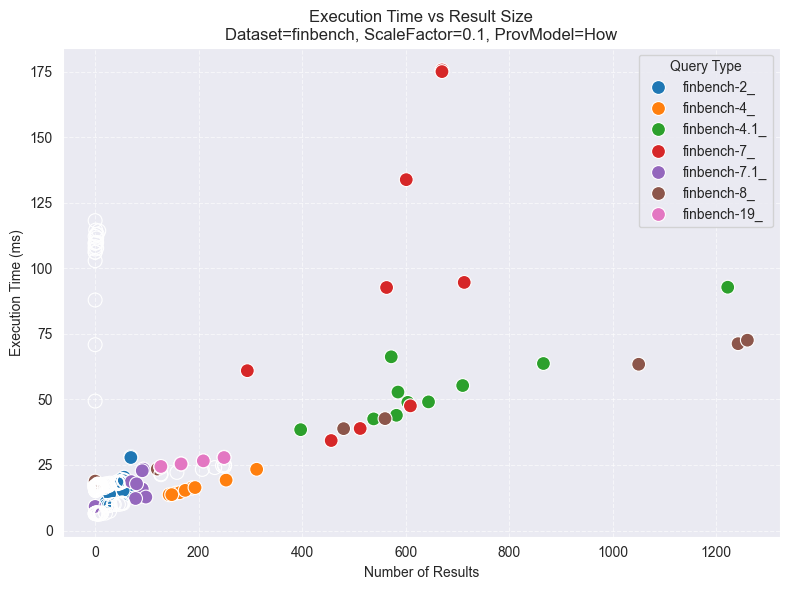

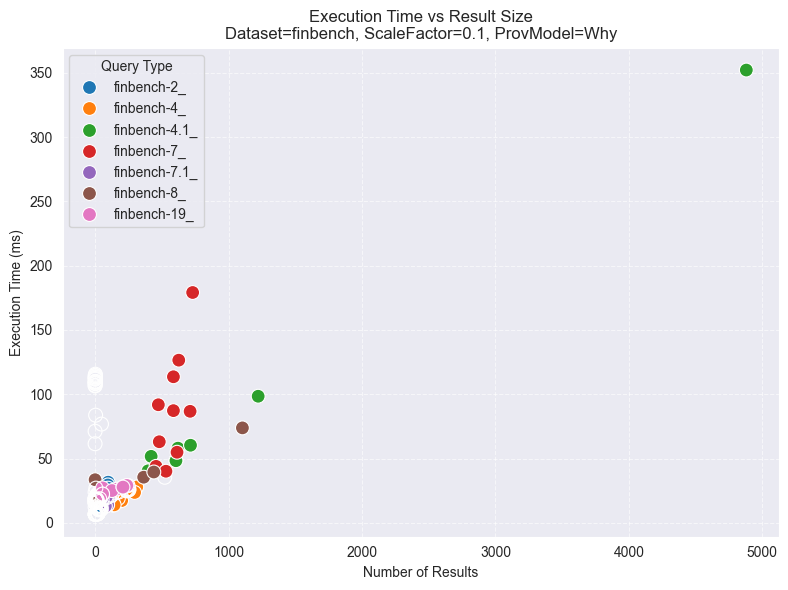

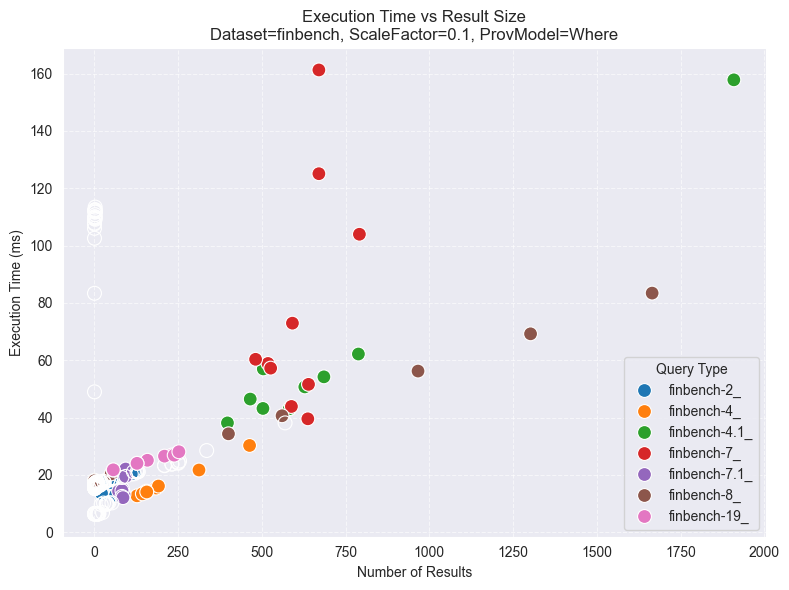

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import re
import numpy as np

# Load CSV
file_name = '2026-01-21_7-with-4n7-alt-1_latency.csv'
df = pd.read_csv(os.path.join('./result/metrics/', file_name))

# Identify query type
df["query_type"] = df["query"].apply(lambda q: "orig" if q.startswith("orig_") else "prov")
df= df[df["query_type"]=="prov"]

# Extract base query name
df["base_query"] = df["query"].str.replace(r"^(orig_|prov_)", "", regex=True)

# df = df[df["base_query"].isin([
#                                 "finbench-2_",
#                                # "finbench-3_",
#                                "finbench-4_",
#                                "finbench-7_",
#                                "finbench-8_",
#                                "finbench-19_"
# ])]

df["adjusted_mean"] = df["mean"]  # or apply any scaling if needed
df["adjusted_results"] = df["resultSize"]

# agg = (
#     df.groupby(["dataset", "scaleFactor", "provModel", "base_query", "query_type"])
#     .agg(total_mean=("adjusted_mean", "sum"), total_results=("resultSize", "sum"))
#     .reset_index()
# )
#
# agg["total_mean"] /= 100
# agg["total_results"] /= 100

# Sort by query number
def query_number(q):
    m = re.search(r"-(\d+)", q)
    return int(m.group(1)) if m else float("inf")
# agg["query_num"] = agg["base_query"].apply(query_number)
# agg = agg.sort_values("query_num")
df["query_num"] = df["base_query"].apply(query_number)
df = df.sort_values("query_num")

# --- Scatter plot per provModel/dataset/scaleFactor ---
datasets = df["dataset"].unique()
scale_factors = df["scaleFactor"].unique()
prov_models = df["provModel"].unique()

for ds in datasets:
    for sf in scale_factors:
        for pm in prov_models:
            subset = df[
                (df["dataset"]==ds) &
                (df["scaleFactor"]==sf) &
                (df["provModel"]==pm)
                ]
            plt.figure(figsize=(8,6))
            sns.scatterplot(
                data=subset,
                x="adjusted_results",
                y="adjusted_mean",
                hue="base_query",
                hue_order=[
                    "finbench-2_",
                    # "finbench-3_",
                    "finbench-4_",
                    "finbench-4.1_",
                    "finbench-7_",
                    "finbench-7.1_",
                    "finbench-8_",
                    "finbench-19_"
                ],
                # ["orig", "prov"],
                s=100  # marker size
            )
            plt.title(f"Execution Time vs Result Size\nDataset={ds}, ScaleFactor={sf}, ProvModel={pm}")
            plt.xlabel("Number of Results")
            plt.ylabel("Execution Time (ms)")
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.legend(title="Query Type")
            plt.tight_layout()
            plt.show()


In [33]:
import pandas as pd
import re

file_name = '2026-01-25_fnb_0.3_naive_latency.csv'
df = pd.read_csv(os.path.join('./result/metrics/', file_name))
# Extract base_query
df["base_query"] = df["query"].str.replace(r"^(orig_|prov_)", "", regex=True)

# Mark hits
df["hit"] = df["resultSize"] > 0

# Calculate hit rate per query (can also group by dataset/scaleFactor/provModel)
hitrate = (
    df.groupby(["dataset", "scaleFactor", "provModel", "base_query"])
    .agg(
        hits=("hit", "sum"),
        total=("hit", "count")
    )
    .reset_index()
)

# Add hit rate column
hitrate["hit_rate"] = hitrate["hits"] / hitrate["total"]

# Sort by query number extracted from base_query
def query_number(q):
    m = re.search(r"-(\d+)", q)
    return int(m.group(1)) if m else float("inf")

hitrate["query_num"] = hitrate["base_query"].apply(query_number)
hitrate = hitrate.sort_values(["provModel","query_num"])

# Keep only relevant columns
hitrate = hitrate[["dataset","scaleFactor","provModel","base_query","hit_rate"]]

hitrate


,dataset,scaleFactor,provModel,base_query,hit_rate
0,finbench,0.3,How,finbench-1.1.1_,0.00
1,finbench,0.3,How,finbench-1.1_,0.00
2,finbench,0.3,How,finbench-1.2_,0.00
3,finbench,0.3,How,finbench-1.3_,0.00
4,finbench,0.3,How,finbench-1.4_,0.00
...,...,...,...,...,...
113,finbench,0.3,Why,finbench-16_,1.00
114,finbench,0.3,Why,finbench-17_,0.00
115,finbench,0.3,Why,finbench-18_,0.95
116,finbench,0.3,Why,finbench-19_,0.90


Saved plot to ./result/plots/mean_execution_time_lines.png


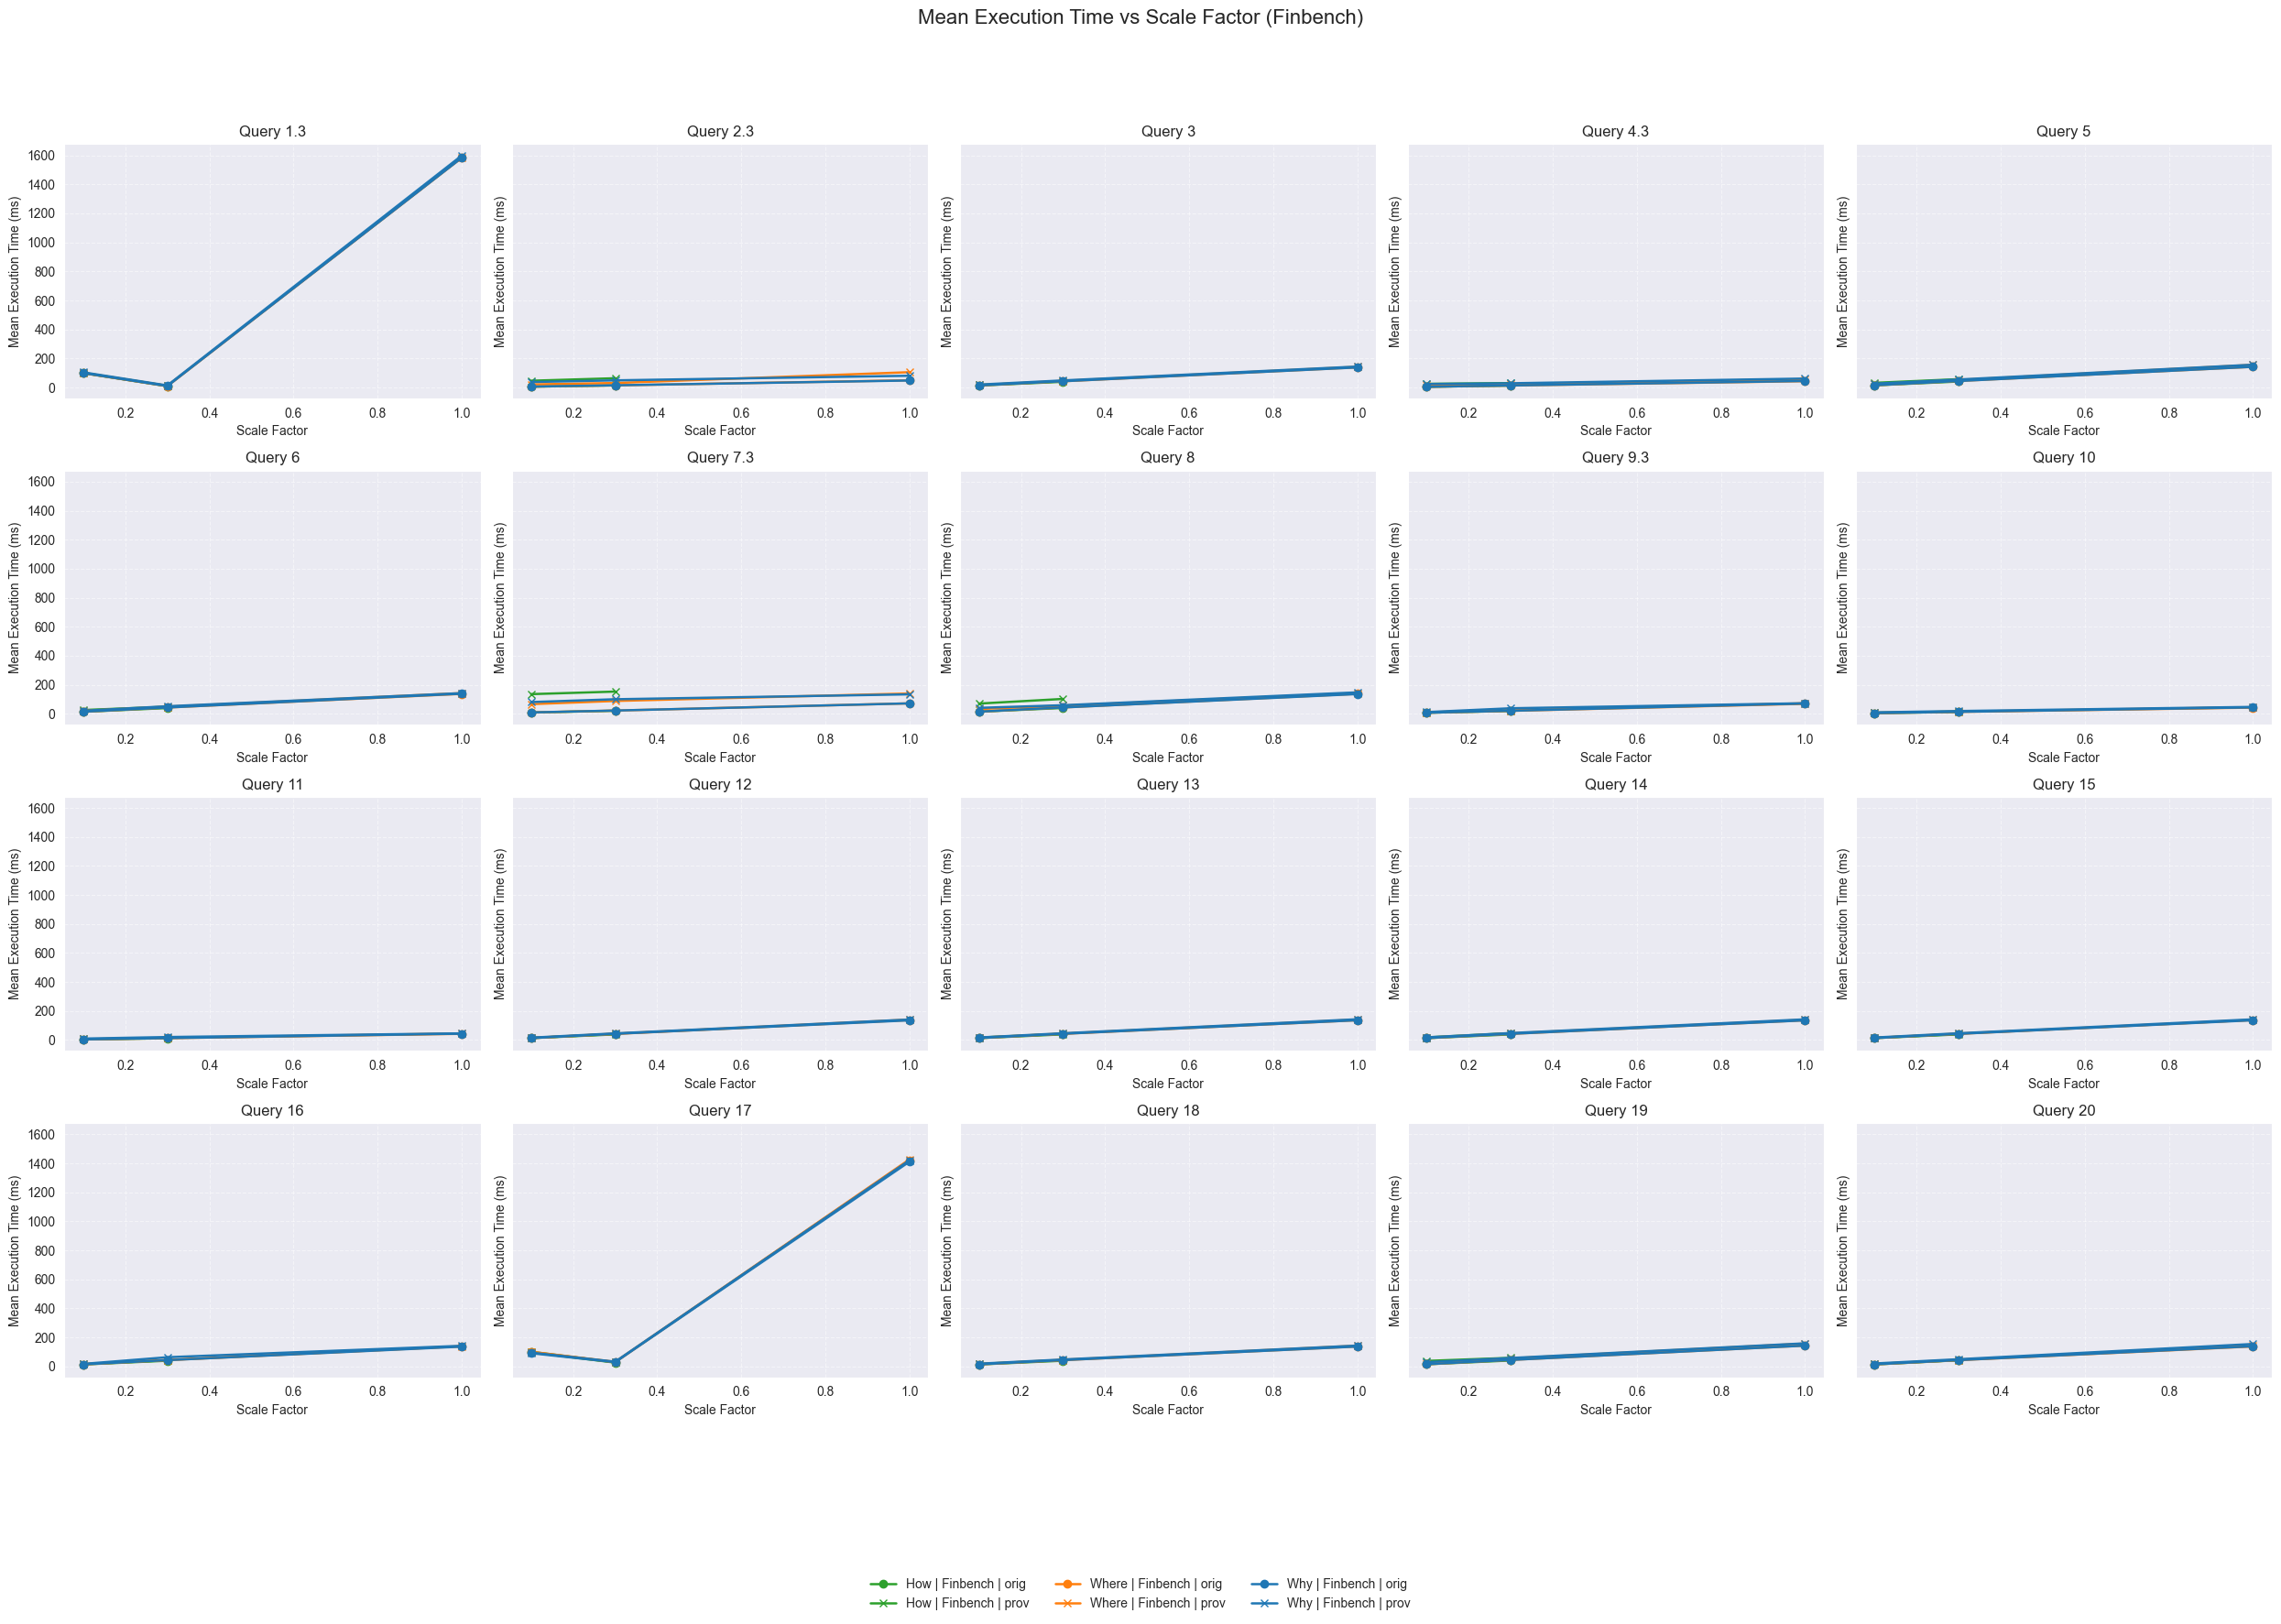

In [27]:
files = [
    "2026-01-25_naive_latency.csv",
    "2026-01-25_fnb_0.3_naive_latency.csv",
    "2026-01-25_fnb_1_naive_latency.csv"
]

df = pd.concat(
    [pd.read_csv(os.path.join("result/metrics", f)) for f in files],
    ignore_index=True
)

df["query_type"] = df["query"].str.extract(r'^(prov|orig)')
df["query_id"] = df["query"].str.extract(
    r'^(?:prov|orig)_(?:finbench|snb)-([\d.]+)_'
)

# Keep only integers or .3 queries
df = df[df["query_id"].str.match(r"^\d+$|^\d+\.3$")]

# Pretty dataset names
dataset_map = {"finbench": "Finbench", "snb": "SNB"}
df["dataset"] = df["dataset"].map(dataset_map).fillna(df["dataset"])

agg = (
    df.groupby(
        ["query_id", "provModel", "dataset", "scaleFactor", "query_type"],
        as_index=False
    )
    .agg(mean_exec_time=("mean", "mean"))
)

def sort_key(q):
    return (int(q.split(".")[0]), q)

query_ids = sorted(agg["query_id"].unique(), key=sort_key)

prov_colors = {
    "Why": "#1f77b4",
    "Where": "#ff7f0e",
    "How": "#2ca02c"
}

marker_map = {
    "orig": "o",
    "prov": "x"
}

n_cols = 5
n_rows = int(np.ceil(len(query_ids) / n_cols))
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharey=True
)
axes = axes.flatten()

for ax, qid in zip(axes, query_ids):
    sub = agg[agg["query_id"] == qid]

    for (provModel, dataset, query_type), g in sub.groupby(
            ["provModel", "dataset", "query_type"]
    ):
        g = g.sort_values("scaleFactor")

        ax.plot(
            g["scaleFactor"],                 # ✅ numeric x → real lines
            g["mean_exec_time"],
            color=prov_colors.get(provModel, "black"),
            marker=marker_map[query_type],
            linestyle="-",
            linewidth=1.8,
            markersize=6,
            label=f"{provModel} | {dataset} | {query_type}"
        )

    ax.set_title(f"Query {qid}")
    ax.set_xlabel("Scale Factor")
    ax.set_ylabel("Mean Execution Time (ms)")
    ax.grid(True, linestyle="--", alpha=0.5)

# Remove empty subplots
for ax in axes[len(query_ids):]:
    fig.delaxes(ax)

#Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=False
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.suptitle("Mean Execution Time vs Scale Factor (Finbench)", fontsize=16, y=1.02)

# Save
output_dir = "./result/plots"
os.makedirs(output_dir, exist_ok=True)
out = f"{output_dir}/mean_execution_time_lines.png"
fig.savefig(out, dpi=300, bbox_inches="tight")
print(f"Saved plot to {out}")

plt.show()


TypeError: unhashable type: 'list'

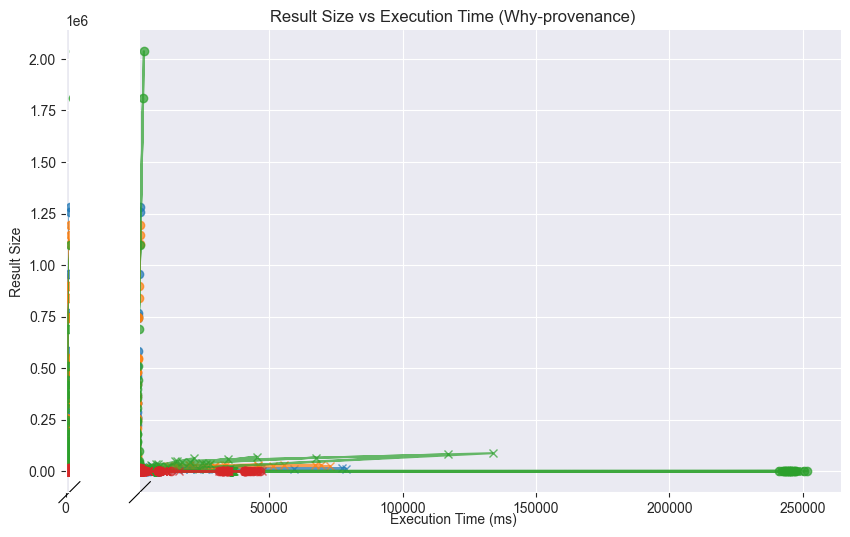

In [42]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from brokenaxes import brokenaxes

# -------------------------
# 1️⃣ Read and combine files
# -------------------------
files = [
    "2026-01-25_naive_latency.csv",
    "2026-01-25_fnb_0.3_naive_latency.csv",
    "2026-01-25_fnb_1_naive_latency.csv",
    "2026-01-25_snb_1_naive_latency.csv"
]

df = pd.concat([pd.read_csv(os.path.join("result/metrics", f)) for f in files], ignore_index=True)

# -------------------------
# 2️⃣ Extract query info
# -------------------------
df["query_type"] = df["query"].str.extract(r'^(prov|orig)')
df["query_id"] = df["query"].str.extract(r'^(?:prov|orig)_[^-]+-(\d+(?:\.\d+)*)_')

dataset_mapping = {"finbench": "Finbench", "snb": "SNB"}
df["dataset"] = df["dataset"].map(dataset_mapping).fillna(df["dataset"])
df = df.dropna(subset=["resultSize", "mean", "provModel", "query_type", "dataset", "scaleFactor"])

# -------------------------
# 3️⃣ Prepare colors and markers
# -------------------------
combos = df[["dataset","scaleFactor"]].drop_duplicates().reset_index(drop=True)
colors = plt.cm.tab10.colors
combo_colors = {tuple(row): colors[i % len(colors)] for i, row in combos.iterrows()}
marker_map = {"orig": "o", "prov": "x"}

output_dir = "./result/plots"
os.makedirs(output_dir, exist_ok=True)

# -------------------------
# 4️⃣ Plot per provenance model with broken x-axis
# -------------------------
for prov_model in ["Why", "Where", "How"]:
    sub = df[df["provModel"] == prov_model]
    if sub.empty:
        continue

    # Split x-axis: low exec times vs high exec times
    split_low = sub["mean"].quantile(0.9)
    split_high = sub["mean"].max() * 1.05

    # Create figure first
    fig = plt.figure(figsize=(10,6))

    # Create broken axes using the figure
    bax = brokenaxes(
        xlims=((0, split_low), (split_low*1.1, split_high)),
        hspace=.05,
        figure=fig
    )

    # Plot each dataset+scaleFactor and query_type
    for (dataset, scale), g in sub.groupby(["dataset","scaleFactor"]):
        color = combo_colors[(dataset, scale)]
        for query_type, gg in g.groupby("query_type"):
            bax.plot(
                gg["mean"],       # x-axis execution time
                gg["resultSize"], # y-axis result size
                marker=marker_map[query_type],
                linestyle='-',    # line connecting points
                color=color,
                alpha=0.7,
                label=f"{dataset}-SF{scale} ({query_type})"
            )

    bax.set_xlabel("Execution Time (ms)")
    bax.set_ylabel("Result Size")
    plt.title(f"Result Size vs Execution Time ({prov_model}-provenance)")

    # Shared legend
    handles, labels = bax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='lower center', ncol=3, frameon=False)

    plt.tight_layout()
    filename = f"{output_dir}/result_size_vs_exec_time_{prov_model}_broken.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved {filename}")
